In [1]:
import math
#import matplotlib
import matplotlib.pyplot as plt
import pathlib
import mne
import numpy as np
import pandas as pd
import glob, os
import pickle
from mne.preprocessing import (ICA, corrmap,find_bad_channels_lof)
from autoreject import (AutoReject,get_rejection_threshold)

# 1 subject

In [4]:
### For testing
pair_n = 2470

folder = f"/Users/s204684/mnt/circling_eeg_data/pair{str(pair_n)}"
os.chdir(folder)

raw = mne.io.read_raw_bdf(glob.glob("*.bdf")[0], verbose=False)

### retrieve channel names
channel_names = raw.ch_names

### pick channels
channels_a = mne.pick_channels_regexp(channel_names, '(1\-.*)|(1\-.*)|(Status)')
channels_b = mne.pick_channels_regexp(channel_names, '(2\-.*)|(2\-.*)|(Status)')

print(f"Channels A: {[channel_names[i] for i in channels_a]}")
print(f"Channels B: {[channel_names[i] for i in channels_b]}")

Channels A: ['1-Fp1', '1-AF7', '1-AF3', '1-F1', '1-F3', '1-F5', '1-F7', '1-FT7', '1-FC5', '1-FC3', '1-FC1', '1-C1', '1-C3', '1-C5', '1-T7', '1-TP7', '1-CP5', '1-CP3', '1-CP1', '1-P1', '1-P3', '1-P5', '1-P7', '1-P9', '1-PO7', '1-PO3', '1-O1', '1-Iz', '1-Oz', '1-POz', '1-Pz', '1-CPz', '1-Fpz', '1-Fp2', '1-AF8', '1-AF4', '1-AFz', '1-Fz', '1-F2', '1-F4', '1-F6', '1-F8', '1-FT8', '1-FC6', '1-FC4', '1-FC2', '1-FCz', '1-Cz', '1-C2', '1-C4', '1-C6', '1-T8', '1-TP8', '1-CP6', '1-CP4', '1-CP2', '1-P2', '1-P4', '1-P6', '1-P8', '1-P10', '1-PO8', '1-PO4', '1-O2', '1-EXG1', '1-EXG2', '1-EXG3', '1-EXG4', '1-EXG5', '1-EXG6', '1-EXG7', '1-EXG8', 'Status']
Channels B: ['2-Fp1', '2-AF7', '2-AF3', '2-F1', '2-F3', '2-F5', '2-F7', '2-FT7', '2-FC5', '2-FC3', '2-FC1', '2-C1', '2-C3', '2-C5', '2-T7', '2-TP7', '2-CP5', '2-CP3', '2-CP1', '2-P1', '2-P3', '2-P5', '2-P7', '2-P9', '2-PO7', '2-PO3', '2-O1', '2-Iz', '2-Oz', '2-POz', '2-Pz', '2-CPz', '2-Fpz', '2-Fp2', '2-AF8', '2-AF4', '2-AFz', '2-Fz', '2-F2', '2-F4', 

<>:13: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:13: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\-'
/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_5615/2522901461.py:13: SyntaxWarning: invalid escape sequence '\-'
  channels_a = mne.pick_channels_regexp(channel_names, '(1\-.*)|(1\-.*)|(Status)')
/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_5615/2522901461.py:14: SyntaxWarning: invalid escape sequence '\-'
  channels_b = mne.pick_channels_regexp(channel_names, '(2\-.*)|(2\-.*)|(Status)')


In [8]:


### separate the data
raw_a = raw.copy().pick(channels_a).set_channel_types({'1-EXG1':'eog','1-EXG2':'eog','1-EXG3':'eog','1-EXG4':'ecg',
                                                    '1-EXG5':'ecg','1-EXG6':'emg','1-EXG7':'emg','1-EXG8':'emg'})
raw_b = raw.copy().pick(channels_b).set_channel_types({'2-EXG1':'eog','2-EXG2':'eog','2-EXG3':'eog','2-EXG4':'ecg',
                                                    '2-EXG5':'ecg','2-EXG6':'emg','2-EXG7':'emg','2-EXG8':'emg'})

### rename channels  
biosemi_layout = mne.channels.make_standard_montage('biosemi64')
biosemi_names = biosemi_layout.ch_names

print(biosemi_names)

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2']


In [9]:

for i in range(len(biosemi_names)):
    raw_a.rename_channels(mapping = {raw_a.ch_names[i]:biosemi_names[i]})

for i in range(len(biosemi_names)):
    raw_b.rename_channels(mapping = {raw_b.ch_names[i]:biosemi_names[i]})

print(f"Channels A renamed: {raw_a.ch_names}" )
print(f"Channels B renamed: {raw_b.ch_names}")

Channels A renamed: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', '1-EXG1', '1-EXG2', '1-EXG3', '1-EXG4', '1-EXG5', '1-EXG6', '1-EXG7', '1-EXG8', 'Status']
Channels B renamed: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', '2-EXG1', '2-EXG2', '2-EXG3', '2-EXG

In [17]:
# print the events
events_a = mne.find_events(raw_a, stim_channel='Status', verbose=False)
events_b = mne.find_events(raw_b, stim_channel='Status', verbose=False)

# print the unique event IDs
print(f"Unique event IDs for subject A: {np.unique(events_a[:, 2])}")
print(f"Unique event IDs for subject B: {np.unique(events_b[:, 2])}")

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130 200]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130 200]


<Epochs | 66 events (all good), 0 – 19.996 s (baseline off), ~170.2 MiB, data loaded,
 'closed_before_start': 22
 'open_start': 22
 'closed_after_start': 22>


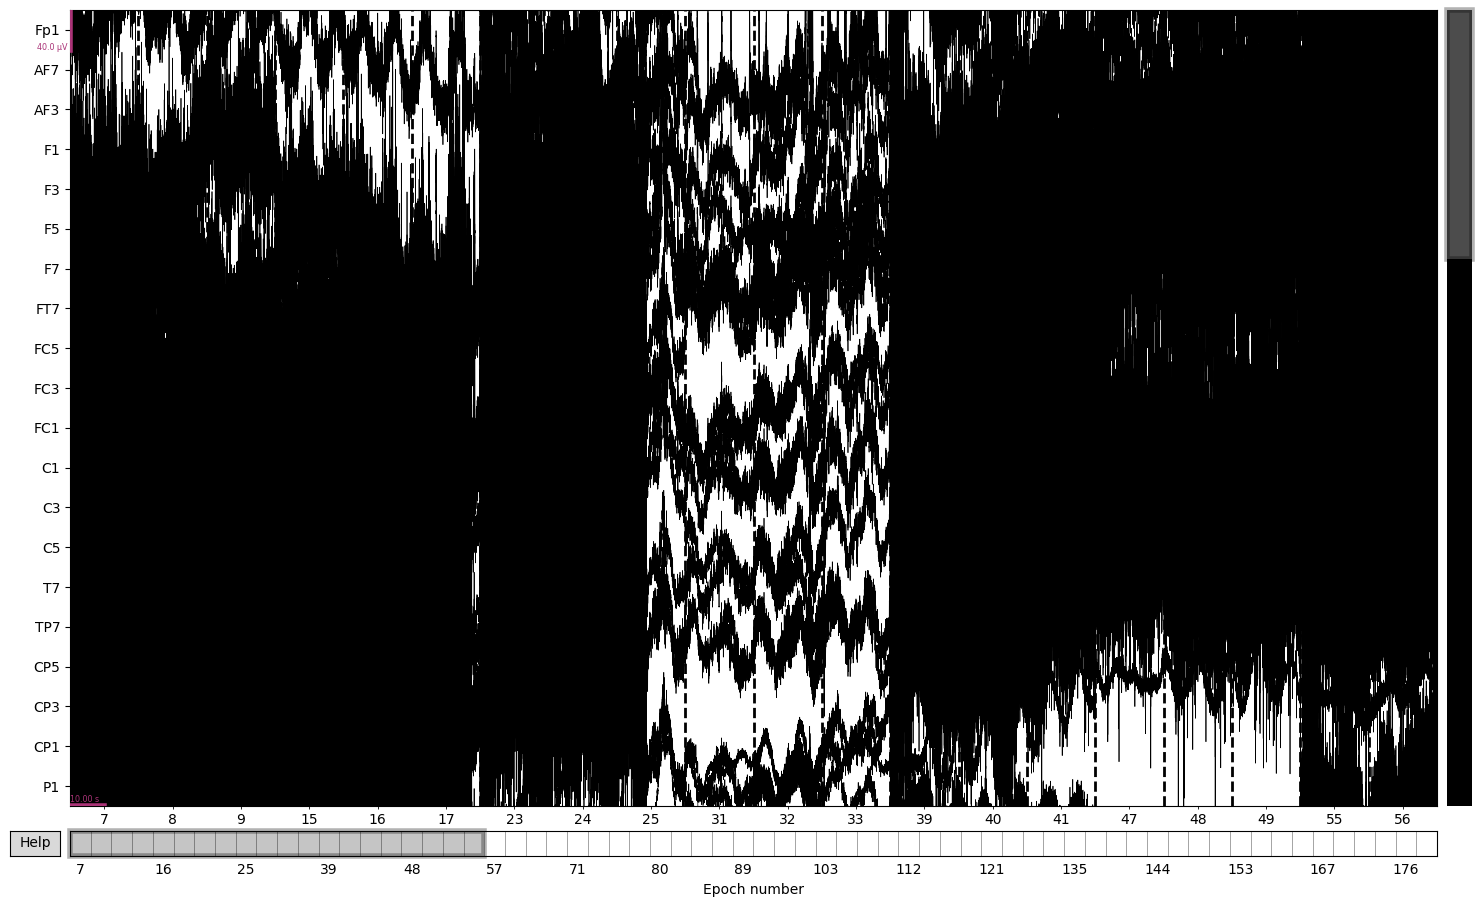

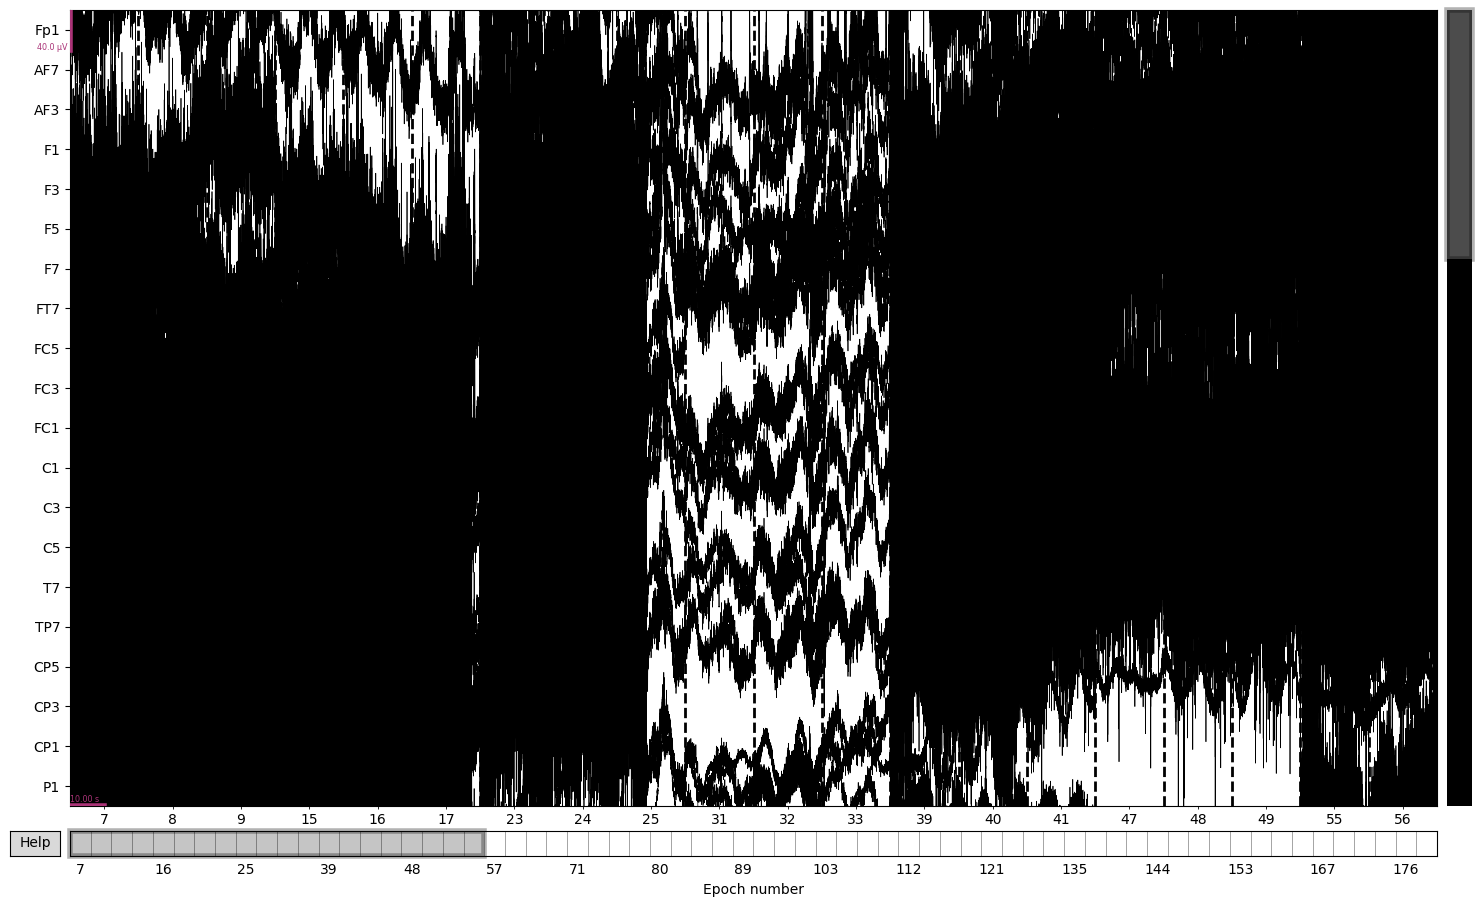

In [10]:

### epoching and downsampling
event_names = {
    "closed_before_start": 11,
    "open_start": 12,
    "closed_after_start": 13
}

events = mne.find_events(raw_a, stim_channel = 'Status',verbose=False)

### — subject A
epochs_a = mne.Epochs(raw_a,
                events=events,
                event_id=event_names,
                tmin=0,
                tmax=20,
                baseline=None,
                picks=['eeg','ecg'],
                preload=True,
                verbose=False)

epochs_res_a = epochs_a.resample(sfreq = 256)
print(epochs_res_a)
epochs_res_a.plot()

# 2. All subjects, starting from filtered data

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


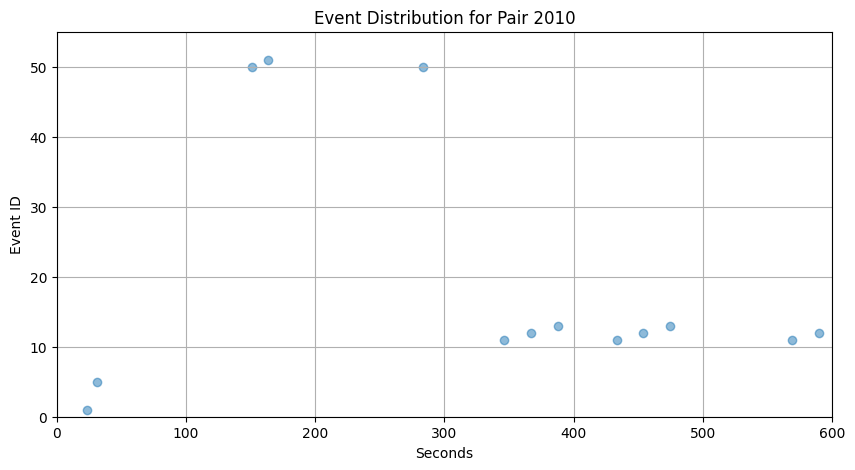

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


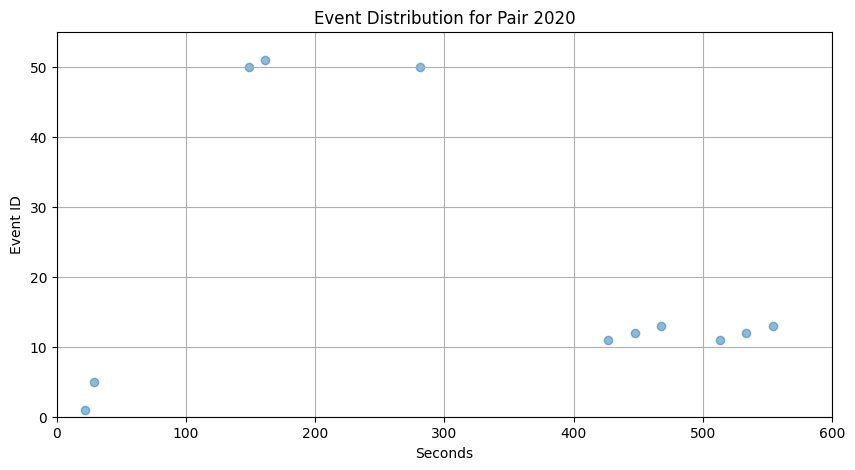

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


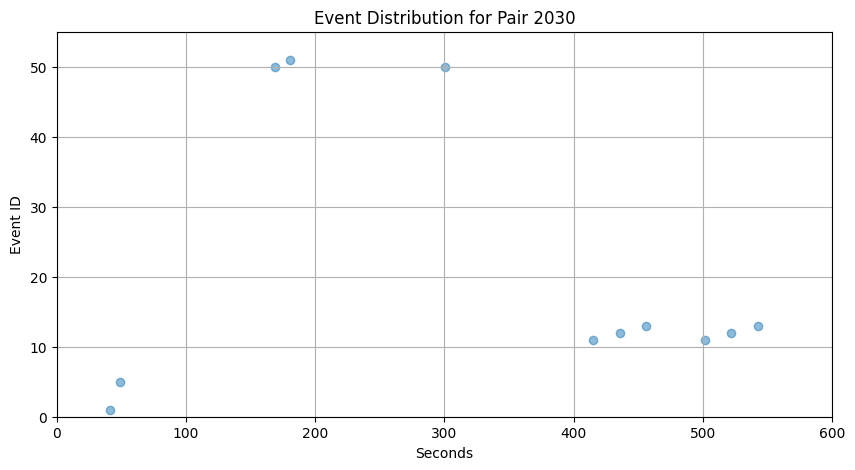

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


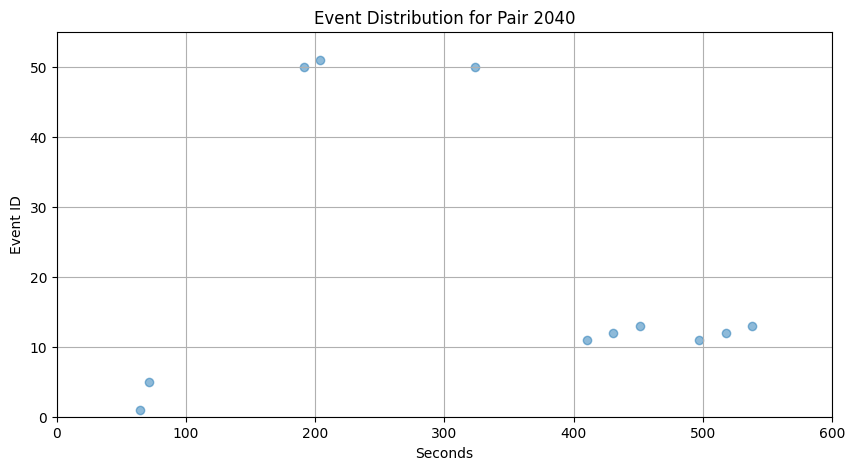

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


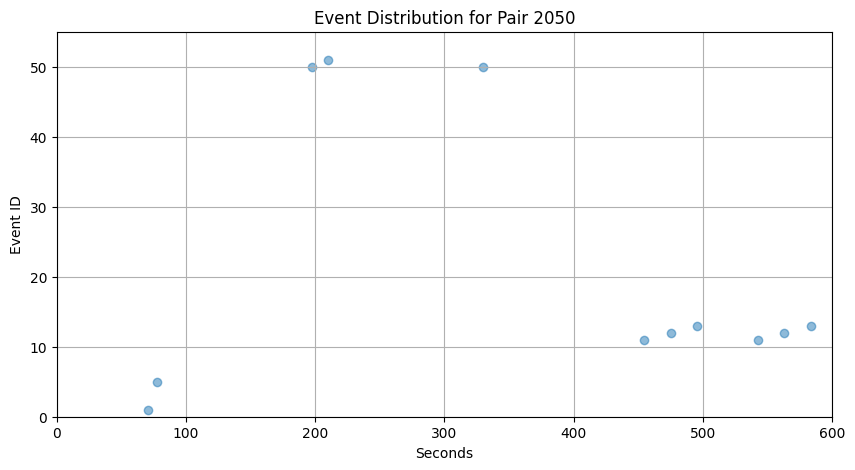

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


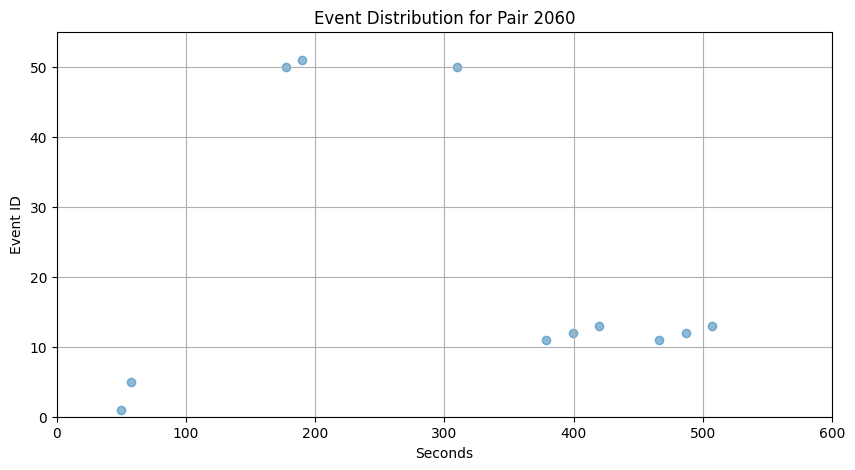

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102]


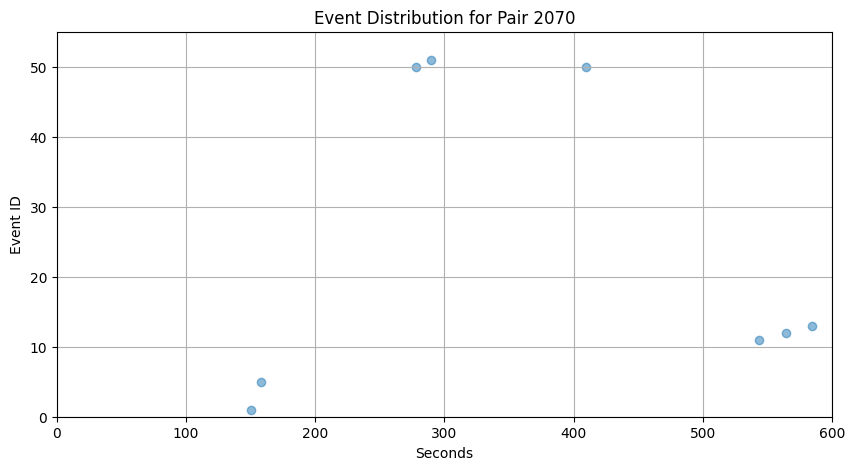

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


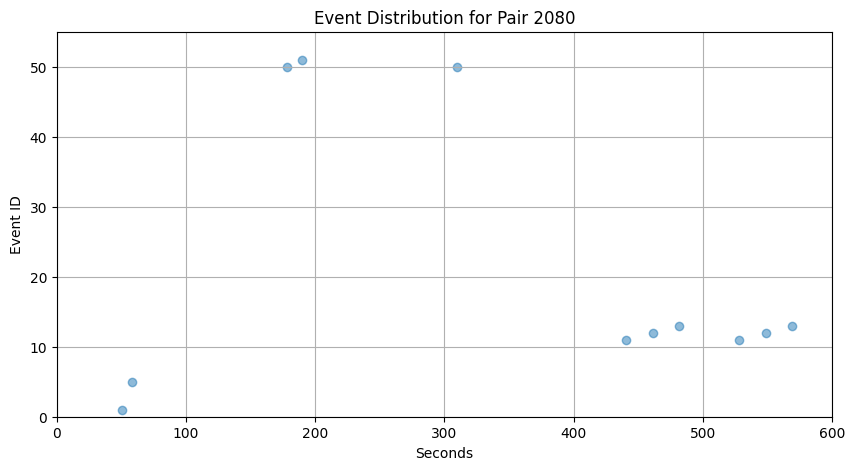

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102]


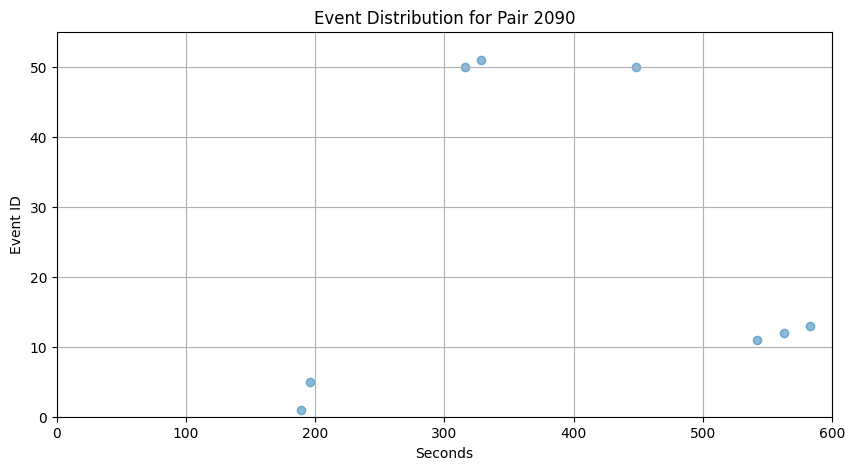

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


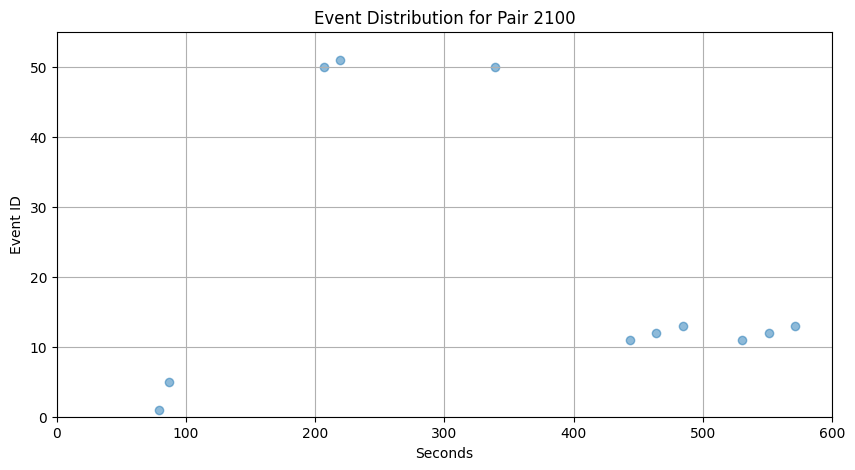

Unique event IDs for subject A: [ 1  5 50 51]
Unique event IDs for subject B: [ 1  5 50 51]


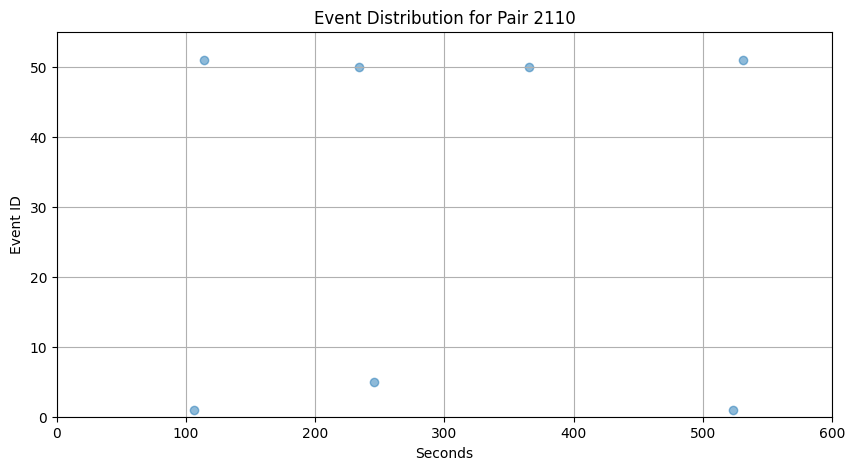

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


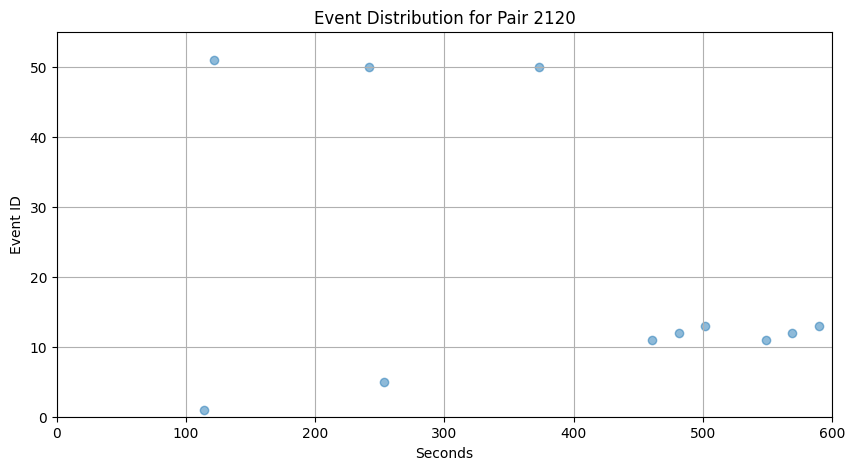

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


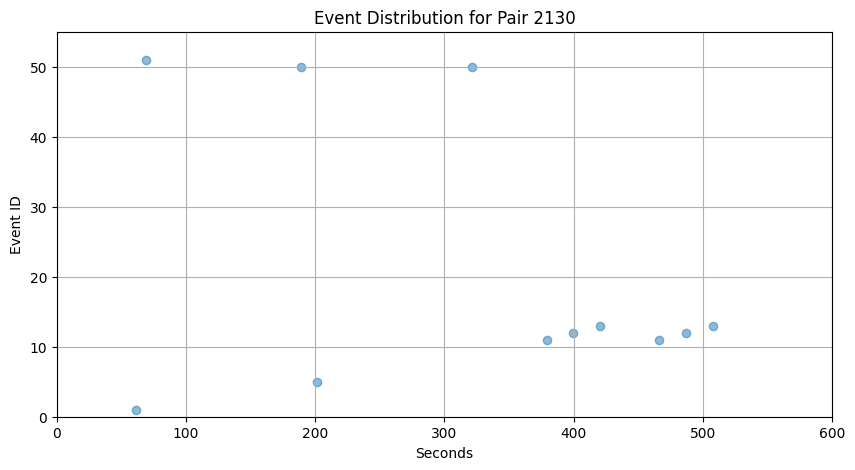

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


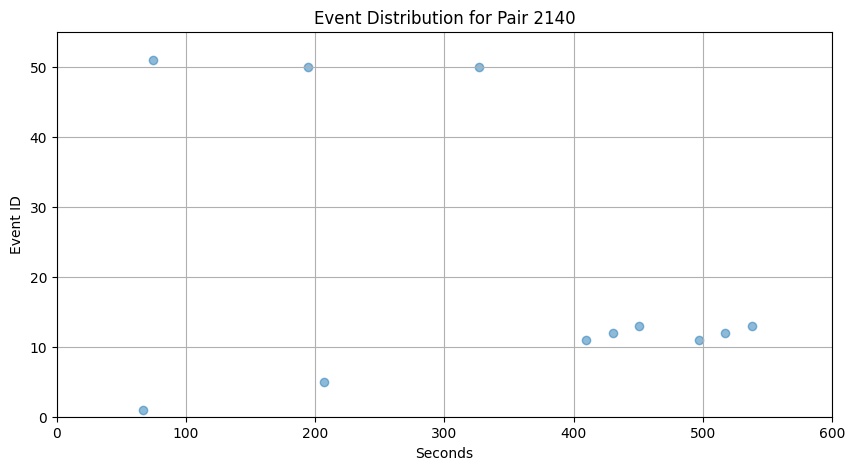

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


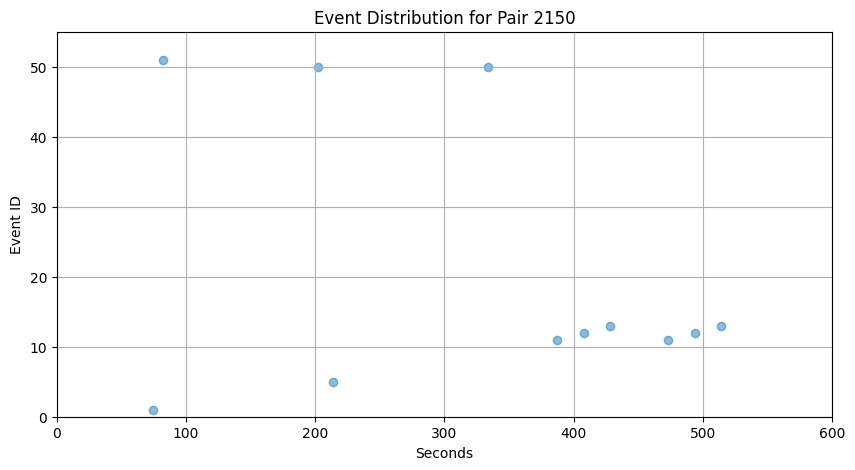

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


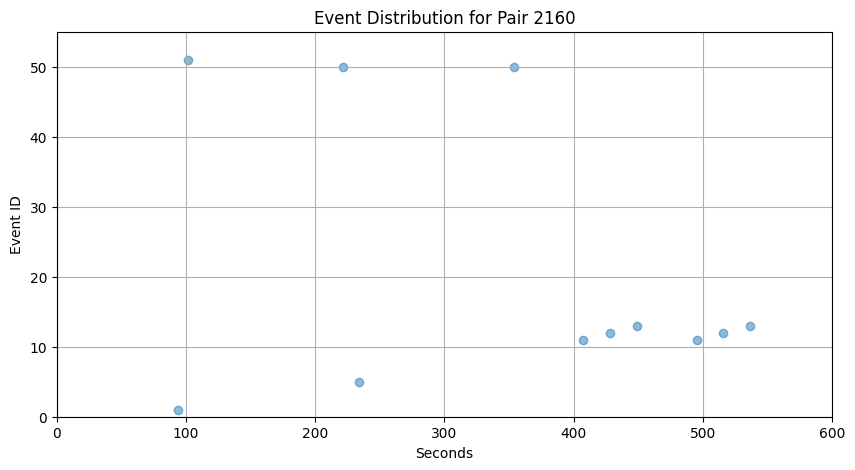

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


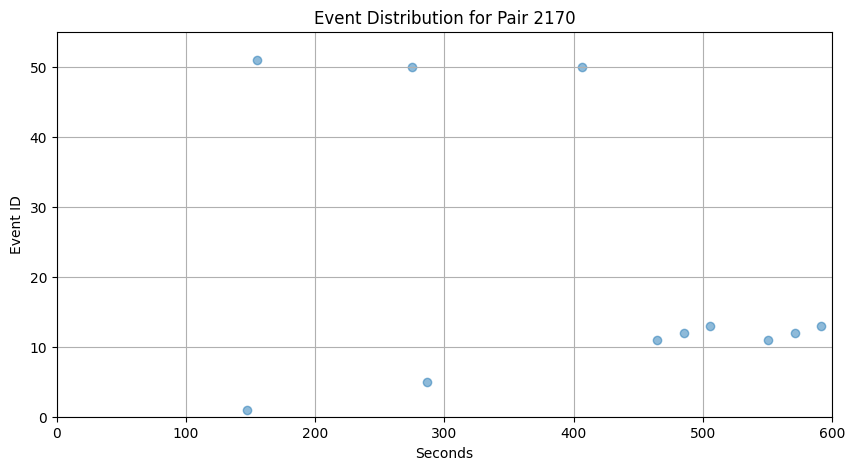

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


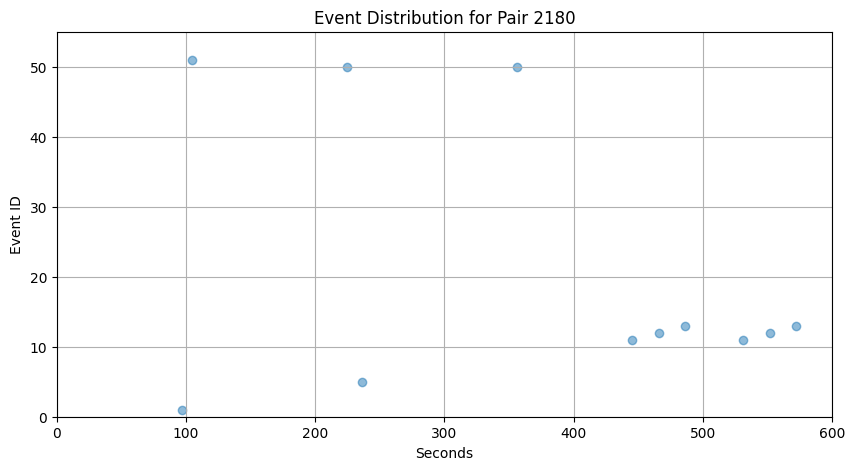

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


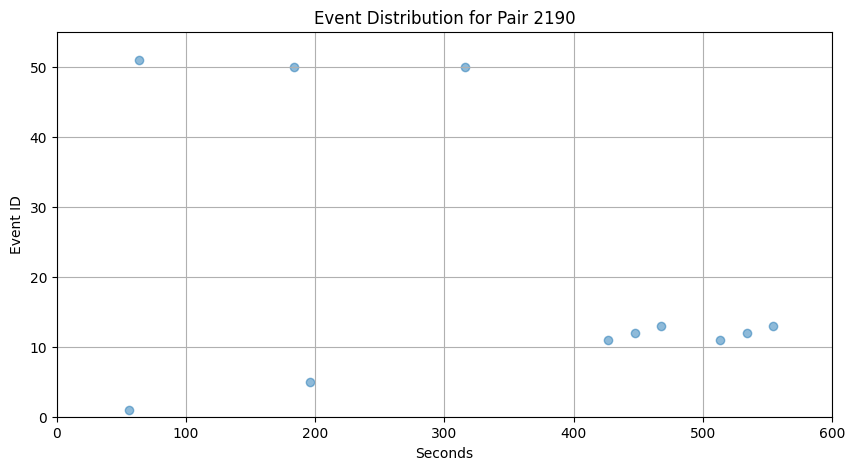

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


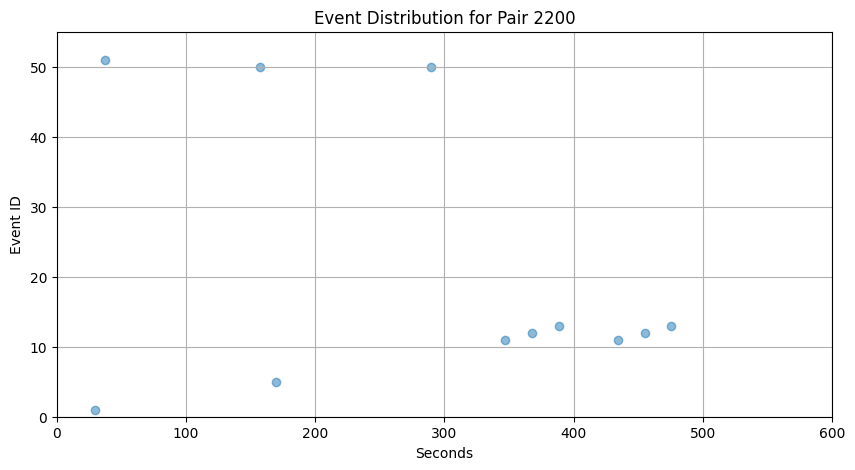

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


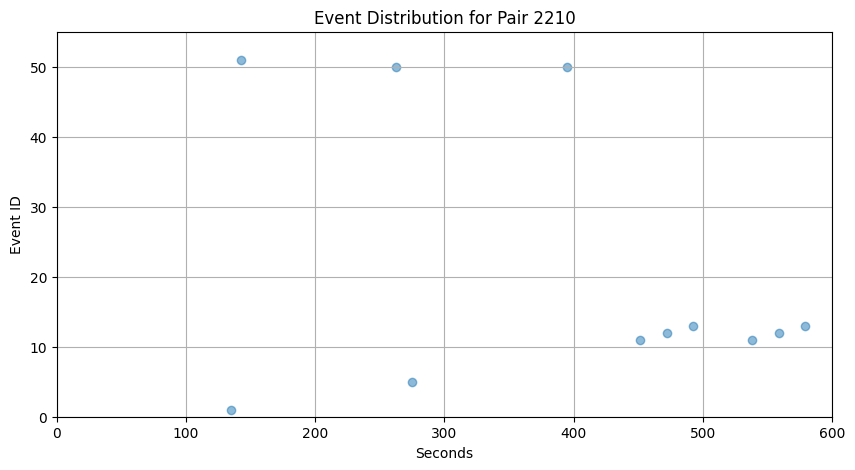

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


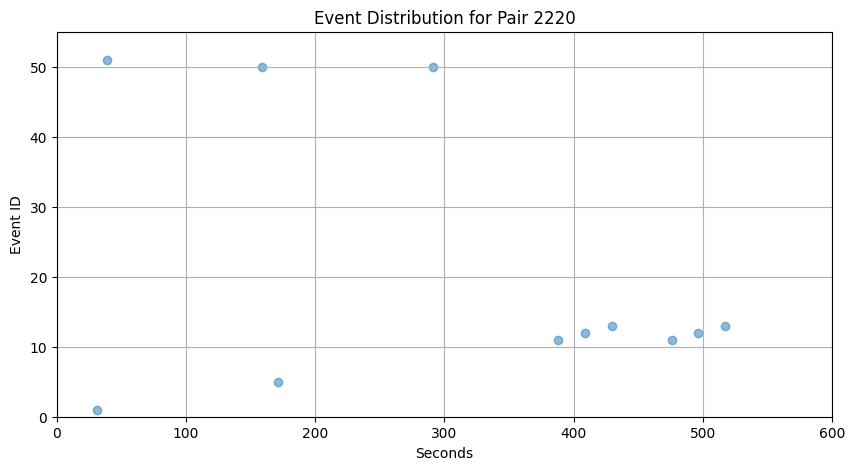

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


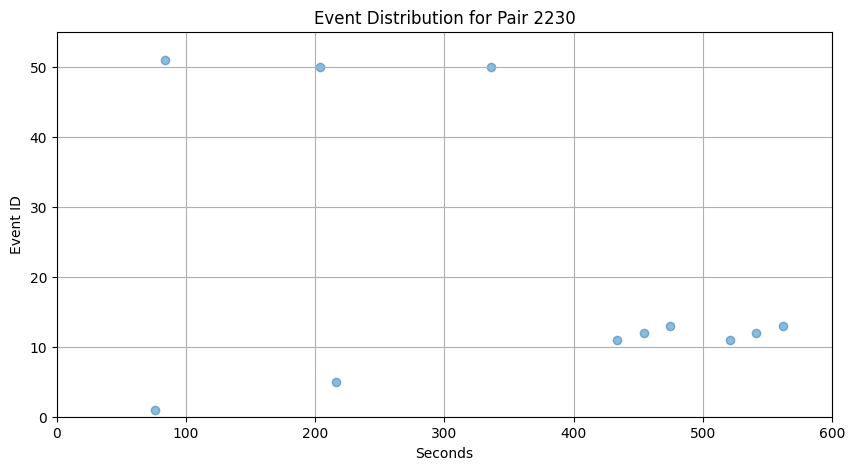

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


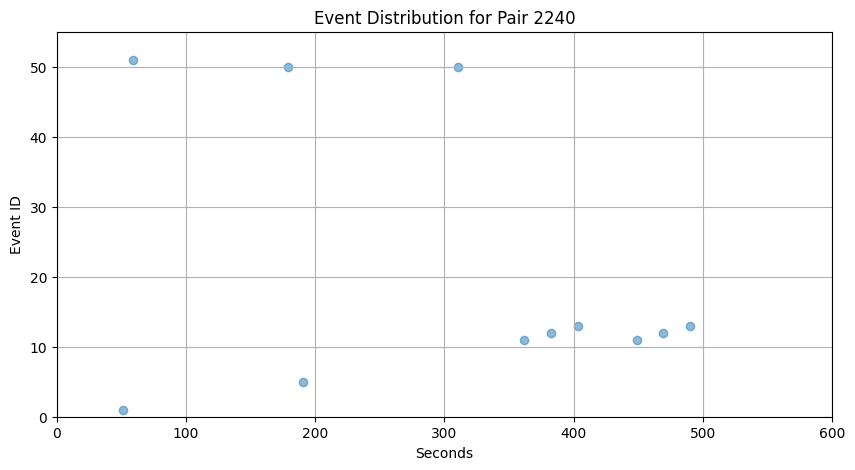

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


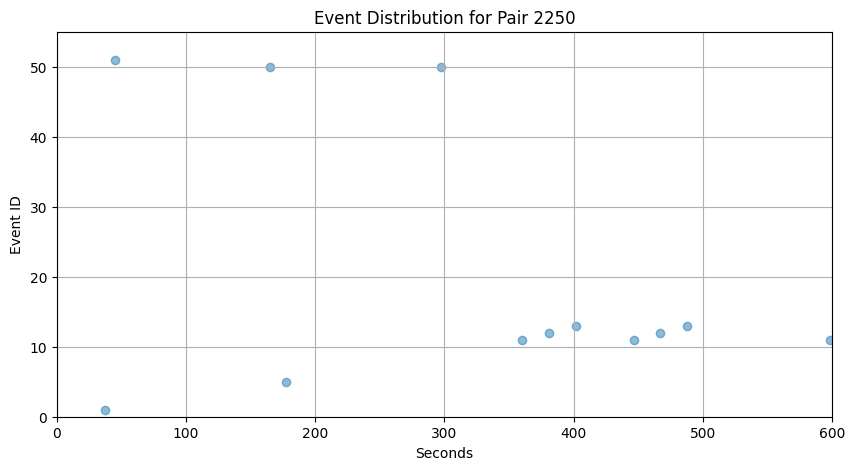

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


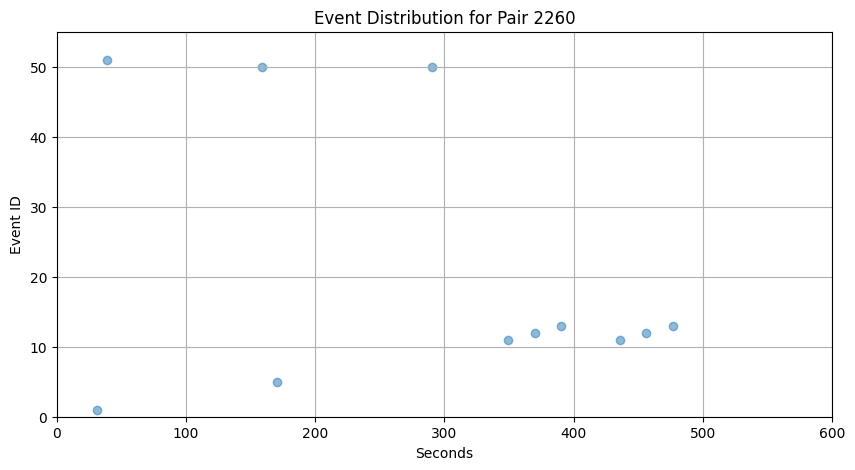

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


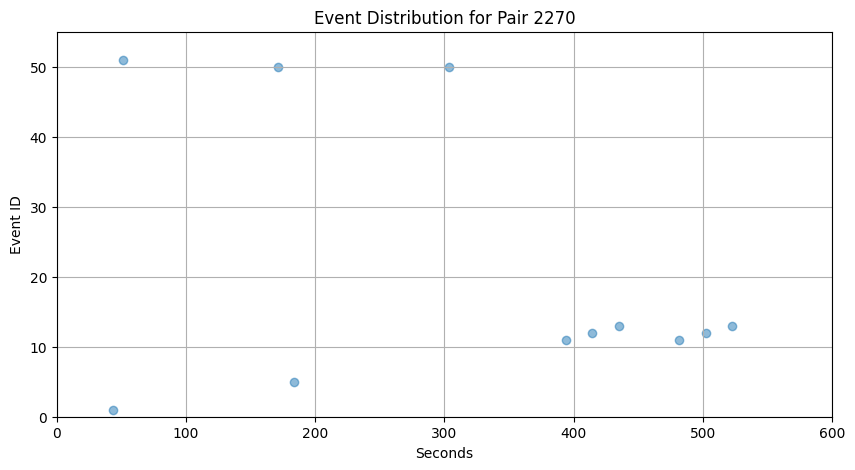

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


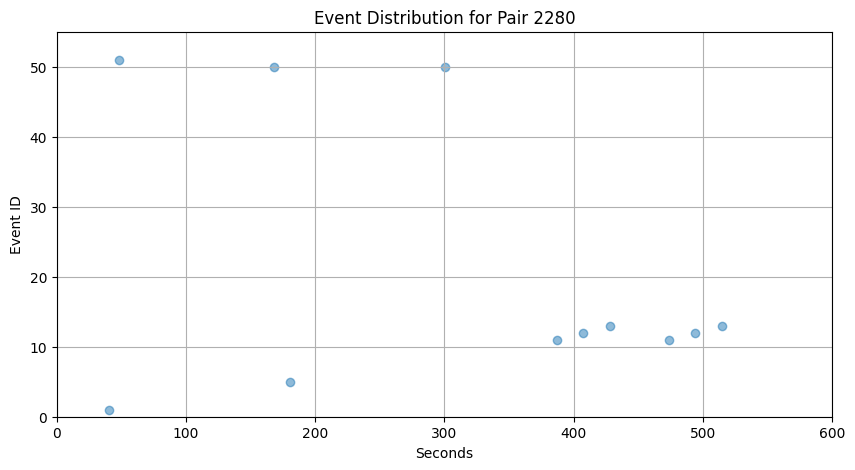

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


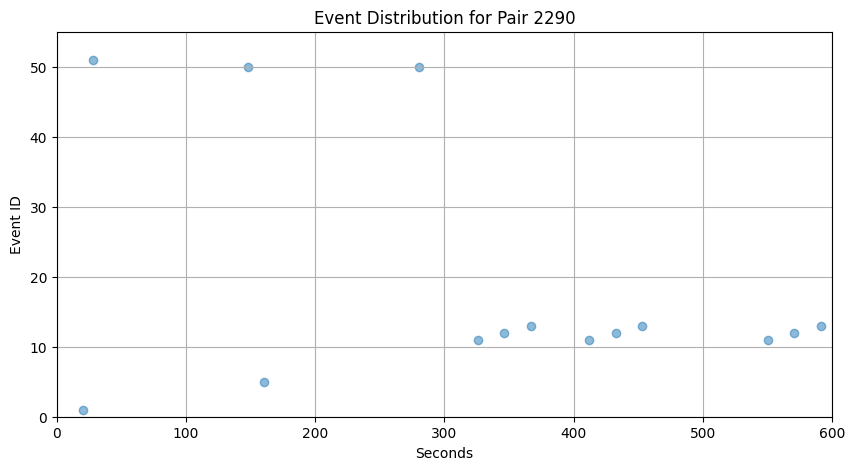

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


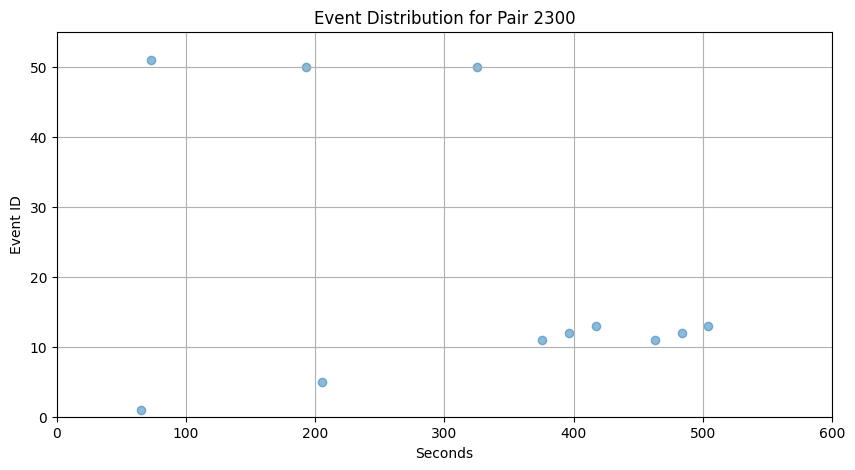

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


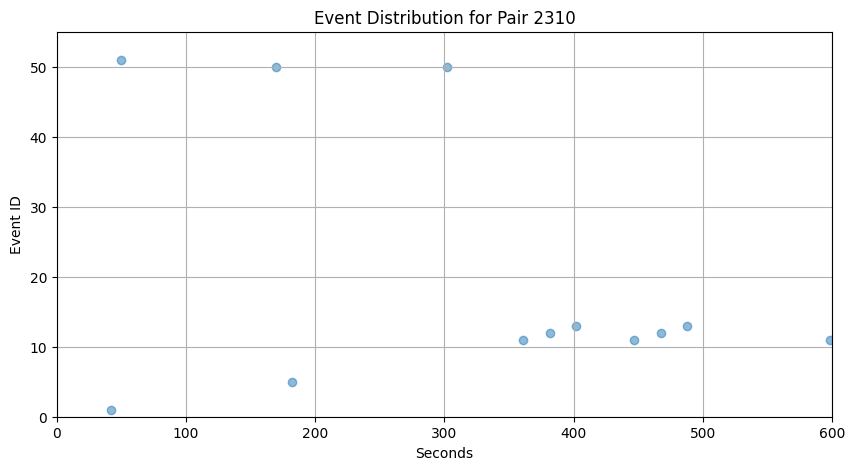

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


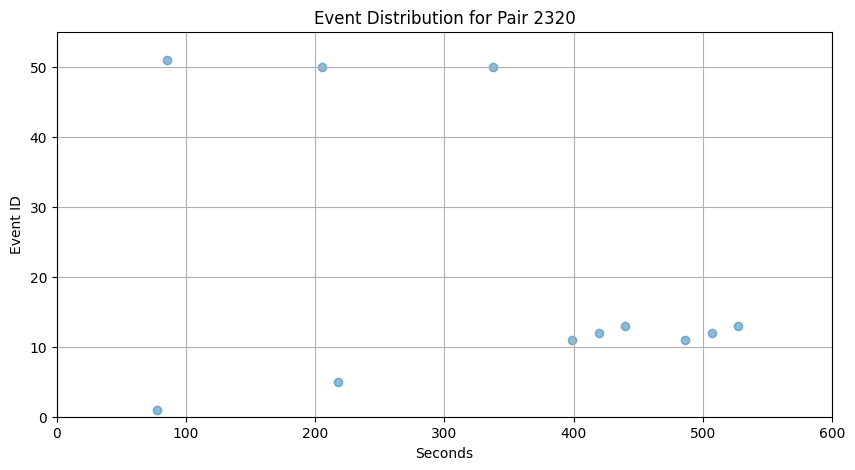

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


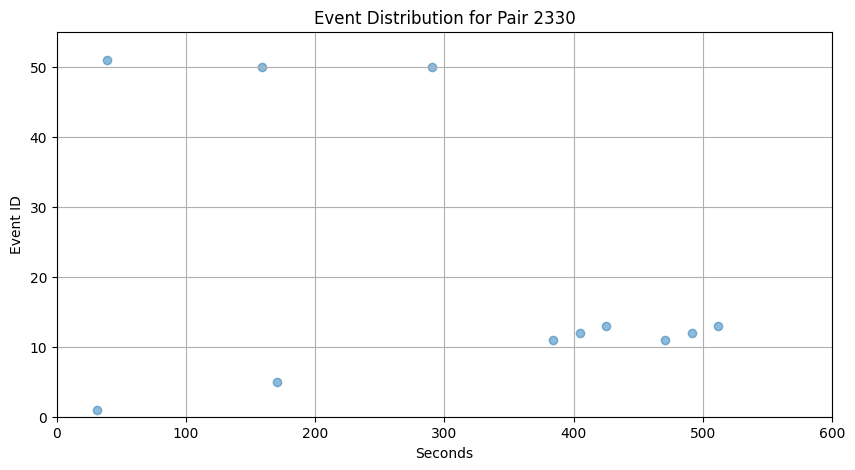

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


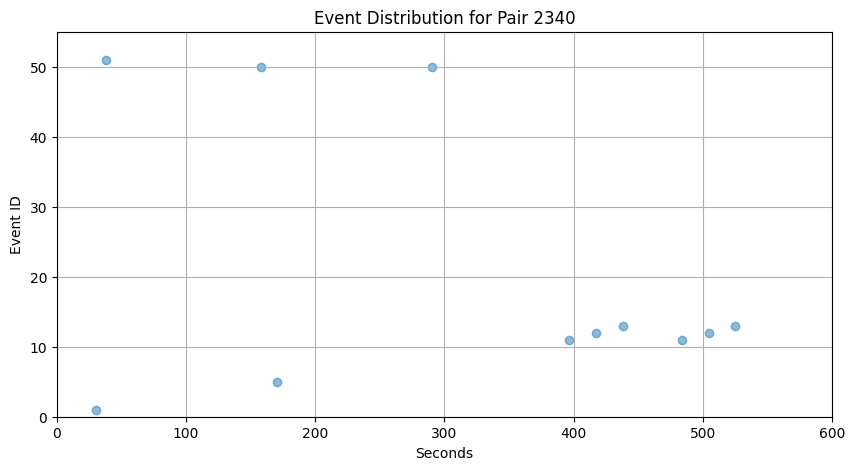

Unique event IDs for subject A: [  1   5  11  12  50  51 101 102]
Unique event IDs for subject B: [  1   5  11  12  50  51 101 102]


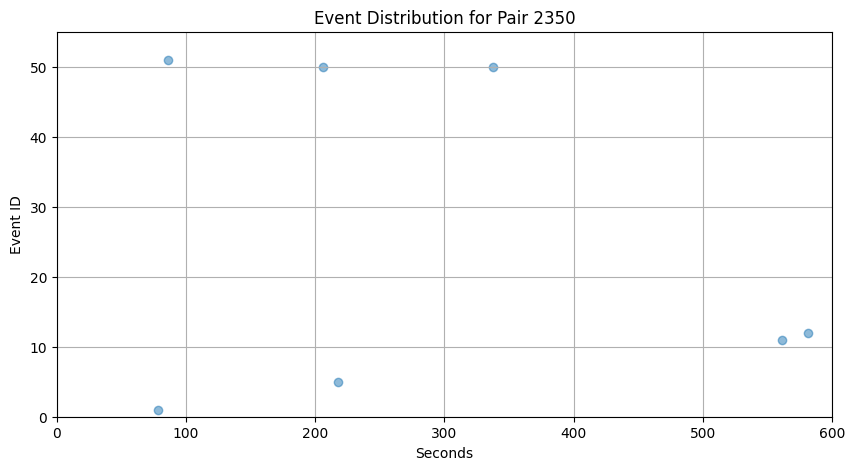

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


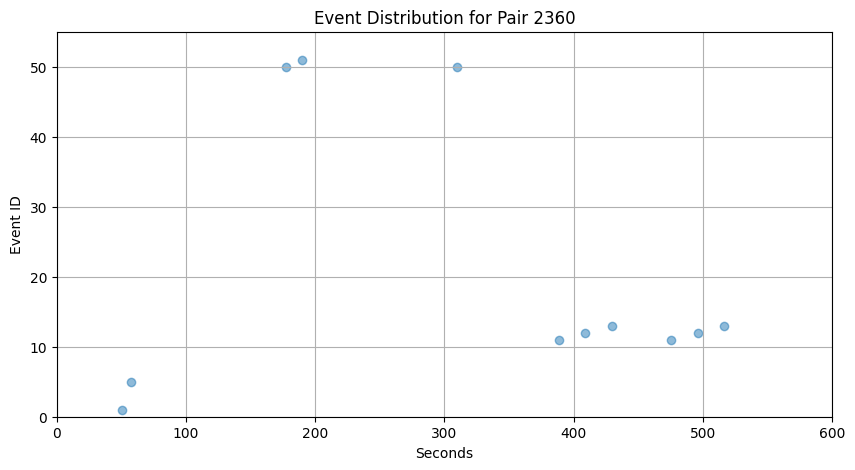

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


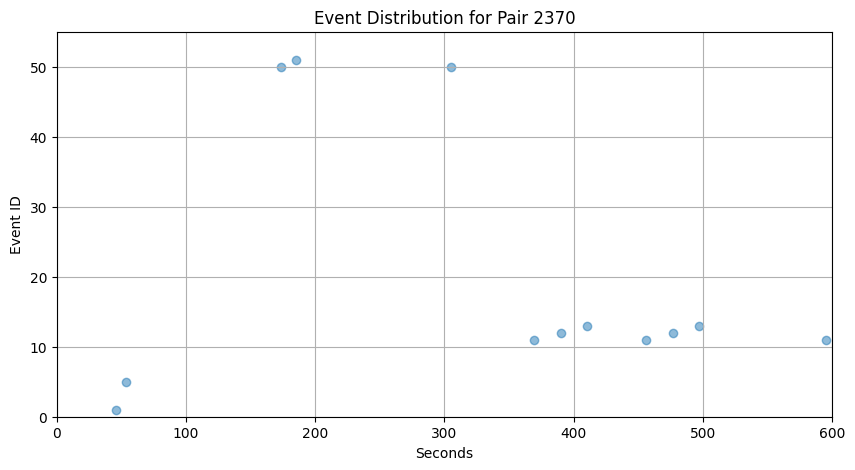

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


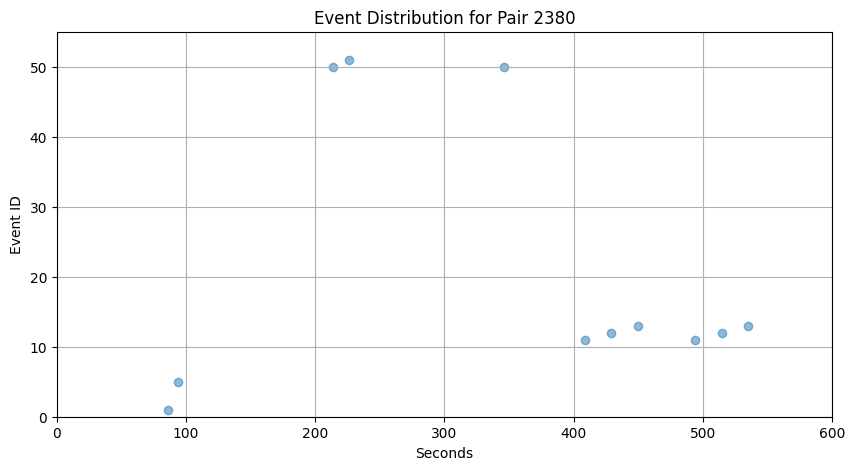

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


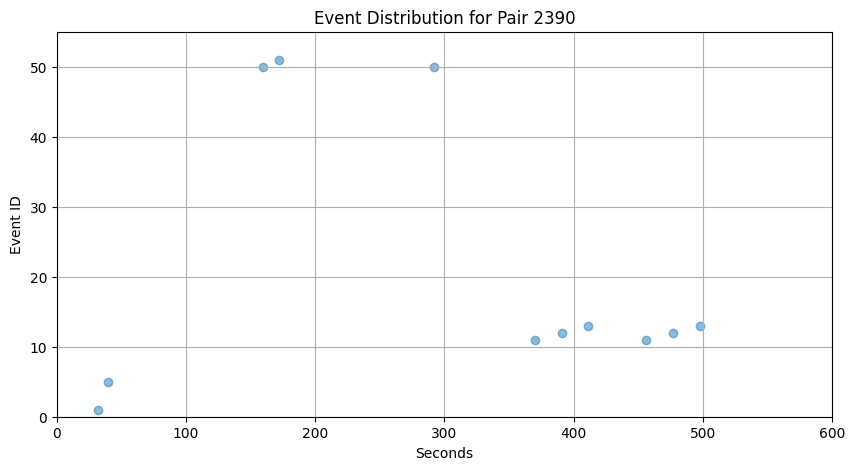

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


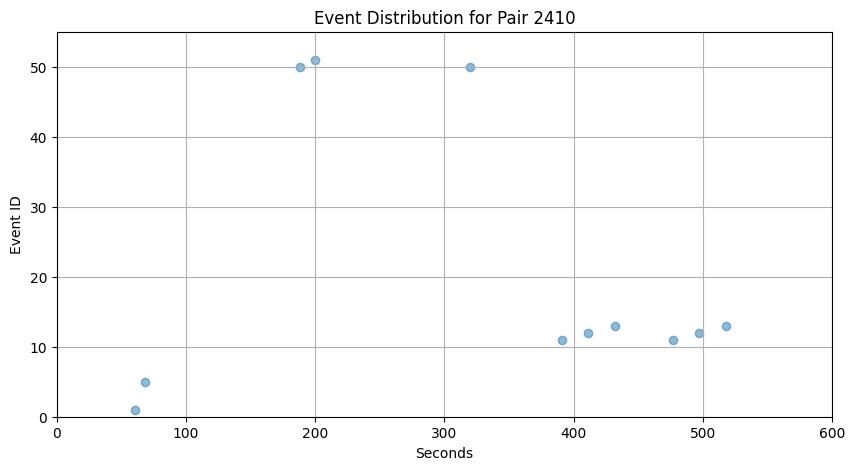

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


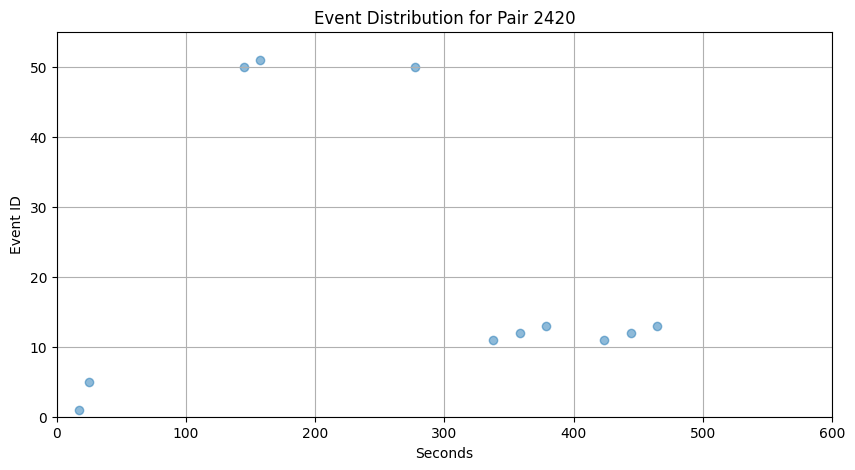

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


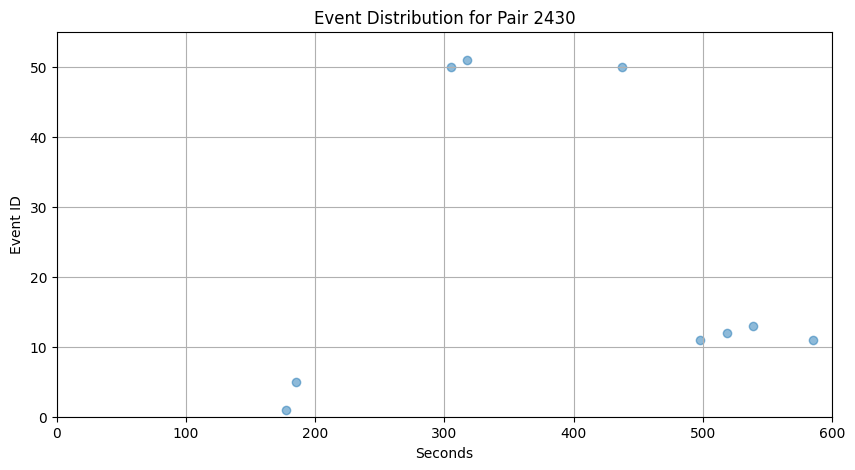

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


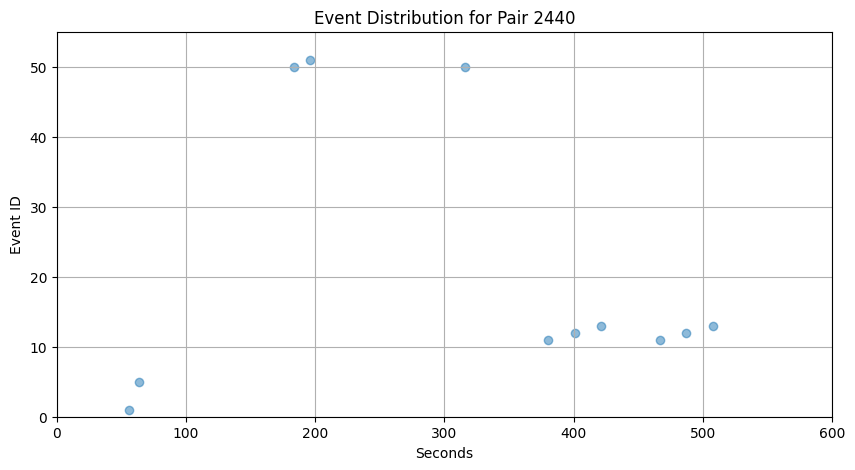

Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]


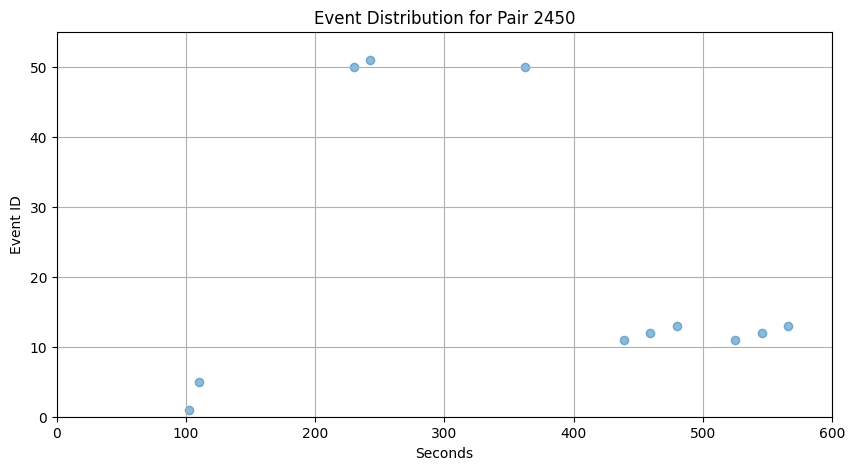

KeyboardInterrupt: 

In [ ]:
all_pairs = [2010,2020,2030,2040,2050,2060,2070,2080,2090,2100,2110,2120,2130,2140,2150,2160,2170,2180,2190,2200,
            2210,2220,2230,2240,2250,2260,2270,2280,2290,2300,2310,2320,2330,2340,2350,2360,2370,2380,2390,
            2410,2420,2430,2440,2450,2460,2470,2480,2490,2500,2510,2520,2530]

# all_pairs = [2010]

for pair_n in all_pairs:
    folder = f"/Users/s204684/mnt/circling_eeg_data/pair{str(pair_n)}"
    os.chdir(folder)

    event_names = {
        "beginning_of_closed_baseline": 5,
        "beginning_of_open_baseline": 51,
        "end_of_baseline": 50,
    }

    filtered_a = mne.io.read_raw_fif('a_filtered_raw.fif',verbose=False).crop(tmax=600)
    events = mne.find_events(filtered_a, stim_channel = 'Status',verbose=False)
    print(f"Unique event IDs for subject A: {np.unique(events[:, 2])}")

    filtered_b = mne.io.read_raw_fif('b_filtered_raw.fif',verbose=False).crop(tmax=600)
    events = mne.find_events(filtered_b, stim_channel = 'Status',verbose=False)
    print(f"Unique event IDs for subject B: {np.unique(events[:, 2])}")

    # check that events are the same for both subjects
    if not np.array_equal(events, mne.find_events(filtered_b, stim_channel = 'Status',verbose=False)):
        print(f"Events do not match for pair {pair_n}")
        break

    # make scatter plot of events
    plt.figure(figsize=(10,5))
    plt.scatter(events[:,0]/filtered_a.info['sfreq'], events[:,2], alpha=0.5)
    # plt.yticks(list(event_names.values()), list(event_names.keys()))
    plt.ylabel('Event ID')
    plt.xlabel('Seconds')
    # set y limit to 55
    plt.ylim(0, 55)
    plt.xlim(0, 600)
    plt.grid()
    plt.title(f'Event Distribution for Pair {pair_n}')
    plt.show()

In [32]:
import mne
import numpy as np
import os

# Your list of pairs
all_pairs = [2010,2020,2030,2040,2050,2060,2070,2080,2090,2100,2110,2120,2130,2140,2150,2160,2170,2180,2190,2200,
            2210,2220,2230,2240,2250,2260,2270,2280,2290,2300,2310,2320,2330,2340,2350,2360,2370,2380,2390,
            2410,2420,2430,2440,2450,2460,2470,2480,2490,2500,2510,2520,2530]

# Define the acceptable tolerance for 120 seconds (e.g., within 0.5 seconds)
TOLERANCE_SECONDS = 0.5
TARGET_DURATION = 120.0

def validate_baseline_durations(raw_data, pair_n, subject_id, target_duration=TARGET_DURATION, tolerance=TOLERANCE_SECONDS):
    """
    Finds events and checks the duration between the specified triggers (5/51 to 50).
    """
    events = mne.find_events(raw_data, stim_channel='Status', verbose=False)
    sfreq = raw_data.info['sfreq']
    
    # Get the sample indices for the critical events
    # We look for the first occurrence of 5, the first occurrence of 51, and the *corresponding* 50s.
    # Given the pattern is either [5, 50, 51, 50] or [51, 50, 5, 50], we need to find the start and end of each segment.
    
    # Find all event 50 (end_of_baseline) samples
    event_50_samples = events[events[:, 2] == 50, 0]
    
    # 1. Closed Baseline (Trigger 5 to 50)
    event_5_sample = events[events[:, 2] == 5, 0]
    if event_5_sample.size > 0:
        event_5_sample = event_5_sample[0]
        # The corresponding 50 is the first one *after* event 5
        event_50_after_5 = event_50_samples[event_50_samples > event_5_sample]
        if event_50_after_5.size > 0:
            end_sample_5 = event_50_after_5[0]
            duration_5_50 = (end_sample_5 - event_5_sample) / sfreq
            
            if abs(duration_5_50 - target_duration) > tolerance:
                print(f"⚠️ **WARNING** for Pair {pair_n} Subject {subject_id}: Closed Baseline (5 -> 50) is {duration_5_50:.2f}s, not {target_duration}s.")
            else:
                print(f"✅ Pair {pair_n} Subject {subject_id}: Closed Baseline (5 -> 50) duration is valid ({duration_5_50:.2f}s).")
        else:
            print(f"🛑 **ERROR** for Pair {pair_n} Subject {subject_id}: Trigger 5 found, but no subsequent 50 found.")
    else:
        print(f"ⓘ **INFO** for Pair {pair_n} Subject {subject_id}: Trigger 5 not found (Expected in one segment).")

    # 2. Open Baseline (Trigger 51 to 50)
    event_51_sample = events[events[:, 2] == 51, 0]
    if event_51_sample.size > 0:
        event_51_sample = event_51_sample[0]
        # The corresponding 50 is the first one *after* event 51
        event_50_after_51 = event_50_samples[event_50_samples > event_51_sample]
        if event_50_after_51.size > 0:
            end_sample_51 = event_50_after_51[0]
            duration_51_50 = (end_sample_51 - event_51_sample) / sfreq
            
            if abs(duration_51_50 - target_duration) > tolerance:
                print(f"⚠️ **WARNING** for Pair {pair_n} Subject {subject_id}: Open Baseline (51 -> 50) is {duration_51_50:.2f}s, not {target_duration}s.")
            else:
                print(f"✅ Pair {pair_n} Subject {subject_id}: Open Baseline (51 -> 50) duration is valid ({duration_51_50:.2f}s).")
        else:
            print(f"🛑 **ERROR** for Pair {pair_n} Subject {subject_id}: Trigger 51 found, but no subsequent 50 found.")
    else:
        print(f"ⓘ **INFO** for Pair {pair_n} Subject {subject_id}: Trigger 51 not found (Expected in one segment).")

# --- Processing Loop ---

for pair_n in all_pairs:
    folder = f"/Users/s204684/mnt/circling_eeg_data/pair{str(pair_n)}"
    
    try:
        os.chdir(folder)
    except FileNotFoundError:
        print(f"Folder not found for pair {pair_n}. Skipping.")
        continue

    print(f"\n--- Checking Pair {pair_n} ---")

    try:
        # Load and process Subject A
        filtered_a = mne.io.read_raw_fif('a_filtered_raw.fif', verbose=False).crop(tmax=600)
        events_a = mne.find_events(filtered_a, stim_channel='Status', verbose=False)
        print(f"Unique event IDs for subject A: {np.unique(events_a[:, 2])}")
        validate_baseline_durations(filtered_a, pair_n, 'A')

        # Load and process Subject B
        filtered_b = mne.io.read_raw_fif('b_filtered_raw.fif', verbose=False).crop(tmax=600)
        events_b = mne.find_events(filtered_b, stim_channel='Status', verbose=False)
        print(f"Unique event IDs for subject B: {np.unique(events_b[:, 2])}")
        validate_baseline_durations(filtered_b, pair_n, 'B')

        # Check that events are the same for both subjects
        if not np.array_equal(events_a, events_b):
            # Note: You used `mne.find_events(filtered_b, ...)` twice in your original check, 
            # I'm fixing it to compare `events_a` and `events_b`.
            print(f"🛑 **CRITICAL ERROR**: Events do not match between subject A and B for pair {pair_n}. Stopping loop.")
            # If this is a hard requirement, uncomment the 'break' below
            # break 

    except FileNotFoundError:
        print(f"🛑 **ERROR**: a_filtered_raw.fif or b_filtered_raw.fif not found in folder for pair {pair_n}. Skipping.")
    except Exception as e:
        print(f"🛑 **UNEXPECTED ERROR** for pair {pair_n}: {e}")


--- Checking Pair 2010 ---
Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
✅ Pair 2010 Subject A: Closed Baseline (5 -> 50) duration is valid (120.00s).
✅ Pair 2010 Subject A: Open Baseline (51 -> 50) duration is valid (120.00s).
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]
✅ Pair 2010 Subject B: Closed Baseline (5 -> 50) duration is valid (120.00s).
✅ Pair 2010 Subject B: Open Baseline (51 -> 50) duration is valid (120.00s).

--- Checking Pair 2020 ---
Unique event IDs for subject A: [  1   5  11  12  13  50  51 101 102 111 112 130]
✅ Pair 2020 Subject A: Closed Baseline (5 -> 50) duration is valid (120.00s).
✅ Pair 2020 Subject A: Open Baseline (51 -> 50) duration is valid (120.00s).
Unique event IDs for subject B: [  1   5  11  12  13  50  51 101 102 111 112 130]
✅ Pair 2020 Subject B: Closed Baseline (5 -> 50) duration is valid (120.00s).
✅ Pair 2020 Subject B: Open Baseline (51 -> 50) duration is valid (120.00

In [ ]:
%matplotlib widget

=== Starting Hyperscanning Baseline Epoching ===
Found 3 pairs to process.

--- Processing Pair 2010 ---
  Found closed baseline start (5) at sample 63368
  Found open baseline start (51) at sample 333961
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


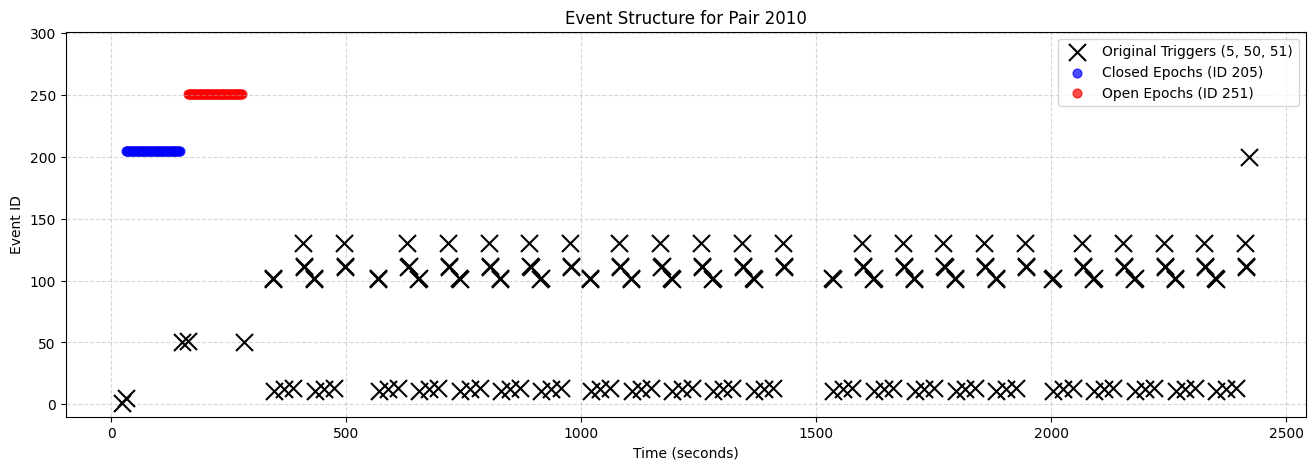


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2010 ---

--- Processing Pair 2020 ---
  Found closed baseline start (5) at sample 59550
  Found open baseline start (51) at sample 330133
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


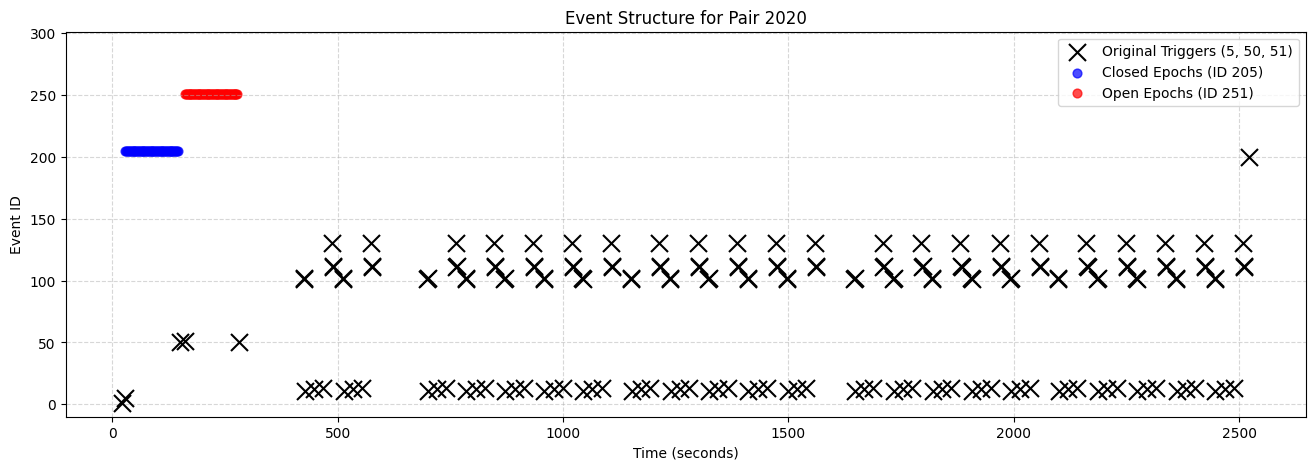


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2020 ---

--- Processing Pair 2130 ---
  Found closed baseline start (5) at sample 411703
  Found open baseline start (51) at sample 141149
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


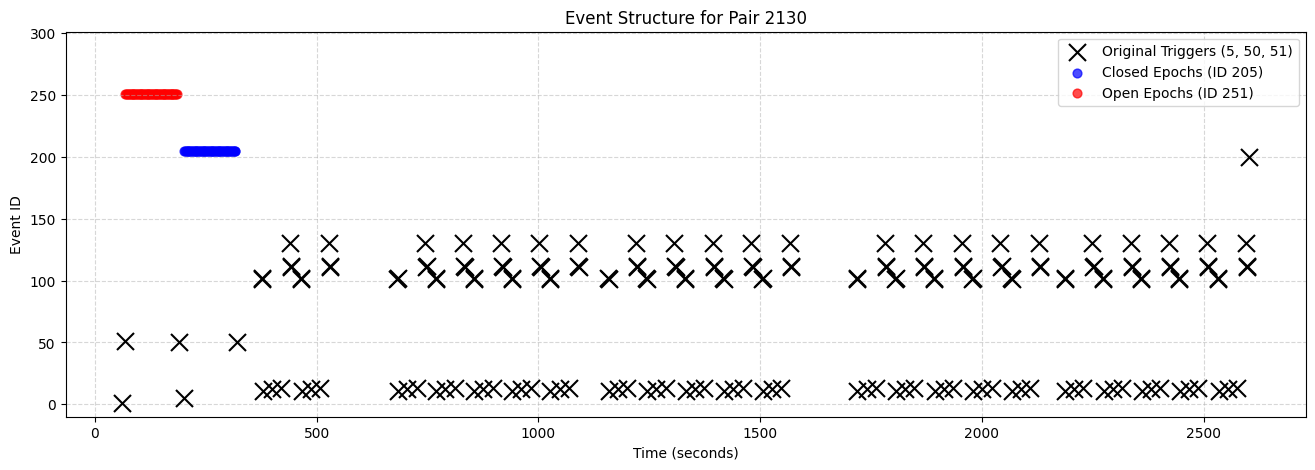


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2130 ---

=== All pairs processed. ===


In [34]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

# Define the base directory for your data
# --- !!! UPDATE THIS PATH !!! ---
base_data_folder = "/Users/s204684/mnt/circling_eeg_data"

# all_pairs = [2010, 2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100, 2110, 2120, 2130, 2140, 2150, 2160, 2170, 2180, 2190, 2200,
#              2210, 2220, 2230, 2240, 2250, 2260, 2270, 2280, 2290, 2300, 2310, 2320, 2330, 2340, 2350, 2360, 2370, 2380, 2390,
#              2410, 2420, 2430, 2440, 2450, 2460, 2470, 2480, 2490, 2500, 2510, 2520, 2530]

all_pairs = [2010, 2020, 2130]

# Define new event IDs for clarity
CLOSED_EPOCH_ID = 205
OPEN_EPOCH_ID = 251

# Define epoching parameters
EPOCH_LEN_SEC = 4.0
STEP_SEC = 2.0  # (for 50% overlap of a 4s epoch)
BASELINE_LEN_SEC = 120.0

print(f"=== Starting Hyperscanning Baseline Epoching ===")
print(f"Found {len(all_pairs)} pairs to process.")

for pair_n in all_pairs:
    print(f"\n--- Processing Pair {pair_n} ---")
    
    pair_folder = os.path.join(base_data_folder, f"pair{str(pair_n)}")
    file_a = os.path.join(pair_folder, 'a_filtered_raw.fif')
    file_b = os.path.join(pair_folder, 'b_filtered_raw.fif')

    try:
        # 1. Load data
        raw_a = mne.io.read_raw_fif(file_a, verbose=False)
        raw_b = mne.io.read_raw_fif(file_b, verbose=False)
        
        # 2. Find original events (using subject A as reference)
        events_a = mne.find_events(raw_a, stim_channel='Status', verbose=False)
        events_b = mne.find_events(raw_b, stim_channel='Status', verbose=False)
        sfreq = raw_a.info['sfreq']
        
        # Your check:
        if not np.array_equal(events_a, events_b):
            print(f"  WARNING: Events do not match for pair {pair_n}! Proceeding with A's events.")
            # We will use events_a as the reference for both
        
        # 3. Find baseline start triggers
        original_event_ids = {
            "beginning_of_closed_baseline": 5,
            "beginning_of_open_baseline": 51,
            "end_of_baseline": 50,
        }
        
        closed_start_events = events_a[events_a[:, 2] == original_event_ids["beginning_of_closed_baseline"]]
        open_start_events = events_a[events_a[:, 2] == original_event_ids["beginning_of_open_baseline"]]
        
        # Robustness checks
        if len(closed_start_events) == 0:
            print(f"  ERROR: Missing 'closed_baseline' (5) trigger. Skipping pair.")
            continue
        if len(open_start_events) == 0:
            print(f"  ERROR: Missing 'open_baseline' (51) trigger. Skipping pair.")
            continue
            
        # Get the first sample of the first trigger (assuming only one)
        closed_start_sample = closed_start_events[0, 0]
        open_start_sample = open_start_events[0, 0]
        
        print(f"  Found closed baseline start (5) at sample {closed_start_sample}")
        print(f"  Found open baseline start (51) at sample {open_start_sample}")

        # 4. Create new events for overlapping epochs
        # We want epoch starts at 0, 2, 4, ... 116 (relative to the trigger)
        # np.arange(start, stop, step)
        # The 'stop' is (120 - 4 + 0.1) = 116.1 to ensure 116 is included
        epoch_starts_sec = np.arange(0, BASELINE_LEN_SEC - EPOCH_LEN_SEC + 0.1, STEP_SEC)
        
        # Convert these times to sample offsets
        epoch_starts_samples = (epoch_starts_sec * sfreq).astype(int)
        
        new_events_list = []
        
        # Create events for closed baseline
        for offset in epoch_starts_samples:
            new_sample = closed_start_sample + offset
            new_events_list.append([new_sample, 0, CLOSED_EPOCH_ID])
            
        # Create events for open baseline
        for offset in epoch_starts_samples:
            new_sample = open_start_sample + offset
            new_events_list.append([new_sample, 0, OPEN_EPOCH_ID])
            
        # Convert to numpy array and sort by time (sample number)
        new_events = np.array(new_events_list)
        new_events = new_events[new_events[:, 0].argsort()]
        
        # 5. Print summary
        n_closed = np.sum(new_events[:, 2] == CLOSED_EPOCH_ID)
        n_open = np.sum(new_events[:, 2] == OPEN_EPOCH_ID)
        print(f"  Created {n_closed} events for 'closed_baseline' (ID {CLOSED_EPOCH_ID})")
        print(f"  Created {n_open} events for 'open_baseline' (ID {OPEN_EPOCH_ID})")

        # 6. Plot the events for visual check
        plt.figure(figsize=(16, 5))
        
        # Plot original triggers
        plt.scatter(events_a[:, 0] / sfreq, events_a[:, 2], 
                    c='black', marker='x', s=150, label='Original Triggers (5, 50, 51)', zorder=10)
        
        # Plot new epoch events
        closed_mask = new_events[:, 2] == CLOSED_EPOCH_ID
        open_mask = new_events[:, 2] == OPEN_EPOCH_ID
        
        plt.scatter(new_events[closed_mask, 0] / sfreq, new_events[closed_mask, 2], 
                    c='blue', marker='o', s=40, alpha=0.7, label=f'Closed Epochs (ID {CLOSED_EPOCH_ID})')
        plt.scatter(new_events[open_mask, 0] / sfreq, new_events[open_mask, 2], 
                    c='red', marker='o', s=40, alpha=0.7, label=f'Open Epochs (ID {OPEN_EPOCH_ID})')
        
        plt.xlabel('Time (seconds)')
        plt.ylabel('Event ID')
        plt.title(f'Event Structure for Pair {pair_n}')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(-10, OPEN_EPOCH_ID + 50) # Adjust ylim to see all events
        plt.show()

        # 7. Create the MNE Epochs objects
        event_id_map = {
            'closed_baseline_epoch': CLOSED_EPOCH_ID,
            'open_baseline_epoch': OPEN_EPOCH_ID
        }
        # tmin=0.0 and tmax=4.0 because our new events mark the *start* of the 4s window
        tmin, tmax = 0.0, EPOCH_LEN_SEC 
        
        epochs_a = mne.Epochs(raw_a, new_events, event_id=event_id_map, tmin=tmin, tmax=tmax, 
                              baseline=None, preload=True, verbose=False)
                              
        epochs_b = mne.Epochs(raw_b, new_events, event_id=event_id_map, tmin=tmin, tmax=tmax, 
                              baseline=None, preload=True, verbose=False)
                              
        print(f"\n  Successfully created Epochs object for subject A:")
        print(epochs_a)
        print(f"  Successfully created Epochs object for subject B:")
        print(epochs_b)
        
        print(f"--- Finished Pair {pair_n} ---")

    except FileNotFoundError:
        print(f"  ERROR: Data file not found for pair {pair_n}. Skipping.")
    except Exception as e:
        print(f"  An UNEXPECTED ERROR occurred for pair {pair_n}: {e}. Skipping.")

print("\n=== All pairs processed. ===")

=== Starting Hyperscanning Baseline Epoching ===
Found 52 pairs to process.

--- Processing Pair 2010 ---
  Found closed baseline start (5) at sample 63368
  Found open baseline start (51) at sample 333961
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


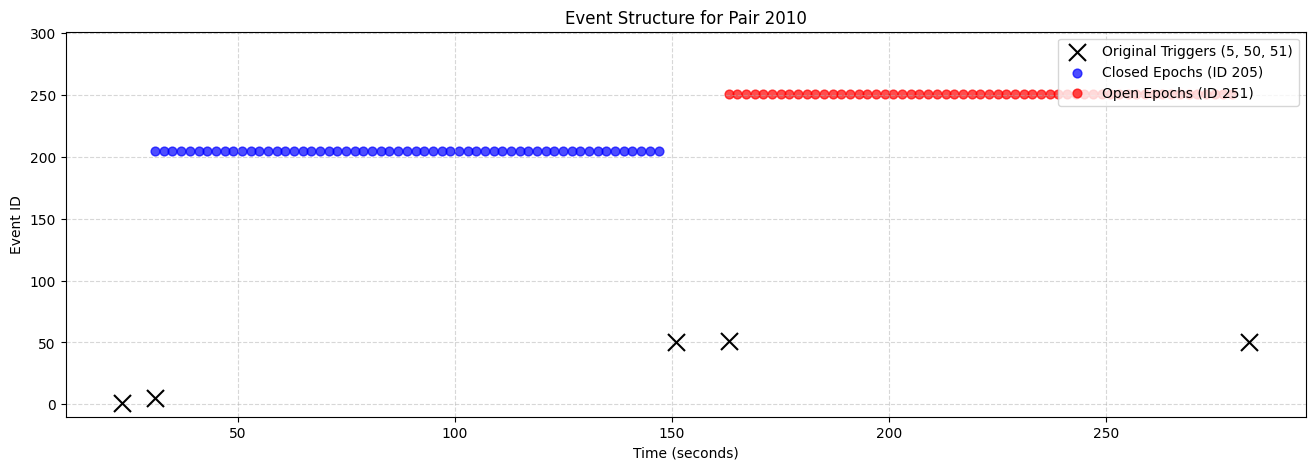


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2010 ---

--- Processing Pair 2020 ---
  Found closed baseline start (5) at sample 59550
  Found open baseline start (51) at sample 330133
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


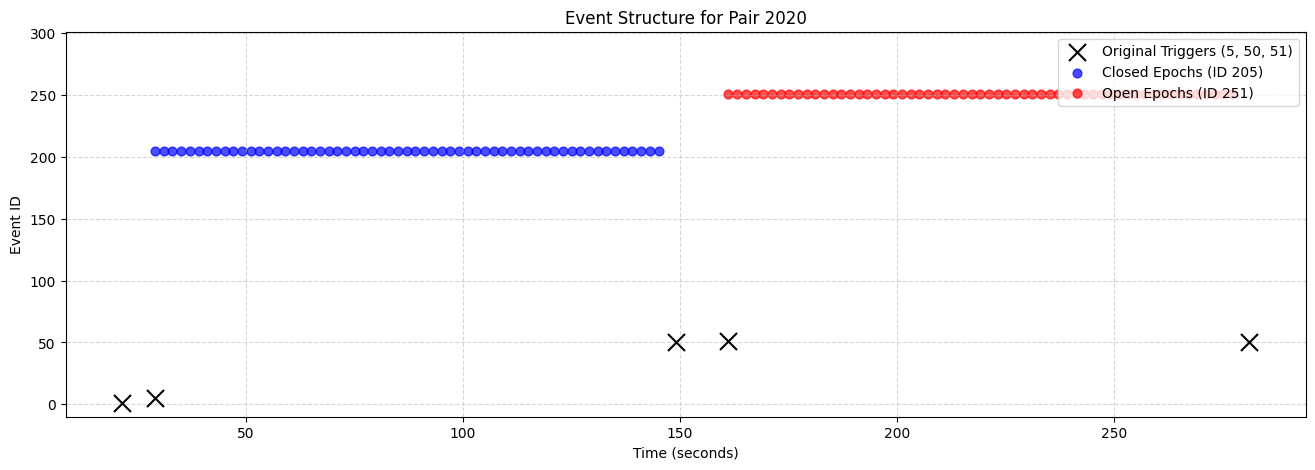


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2020 ---

--- Processing Pair 2030 ---
  Found closed baseline start (5) at sample 99508
  Found open baseline start (51) at sample 370095
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


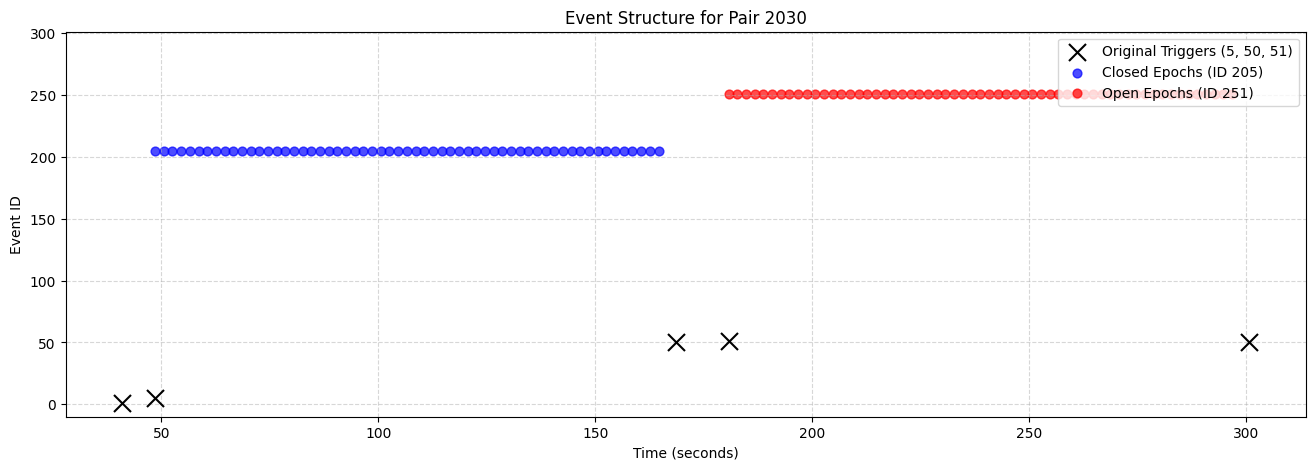


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2030 ---

--- Processing Pair 2040 ---
  Found closed baseline start (5) at sample 146805
  Found open baseline start (51) at sample 417387
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


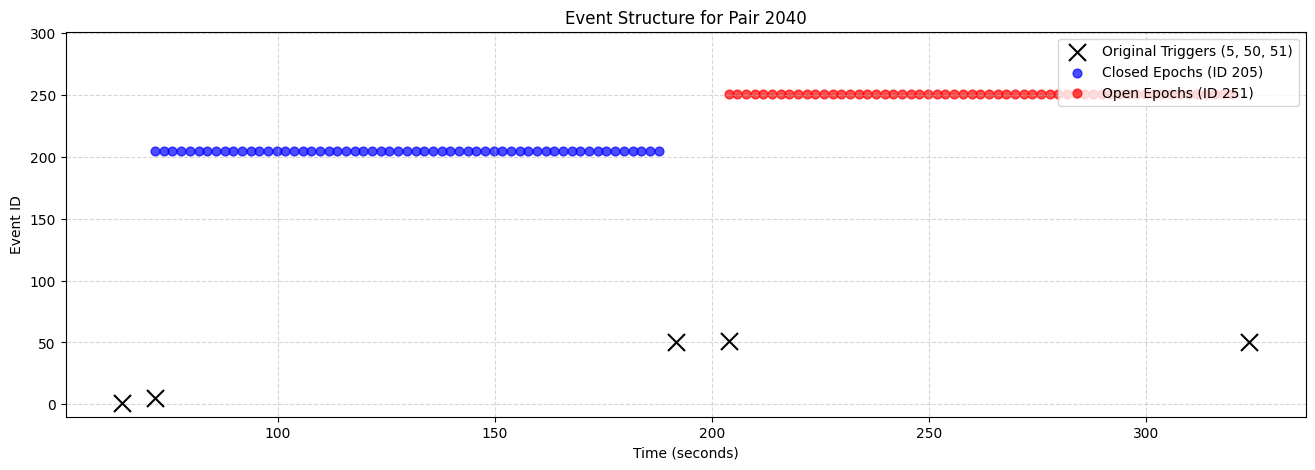


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2040 ---

--- Processing Pair 2050 ---
  Found closed baseline start (5) at sample 159494
  Found open baseline start (51) at sample 430079
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


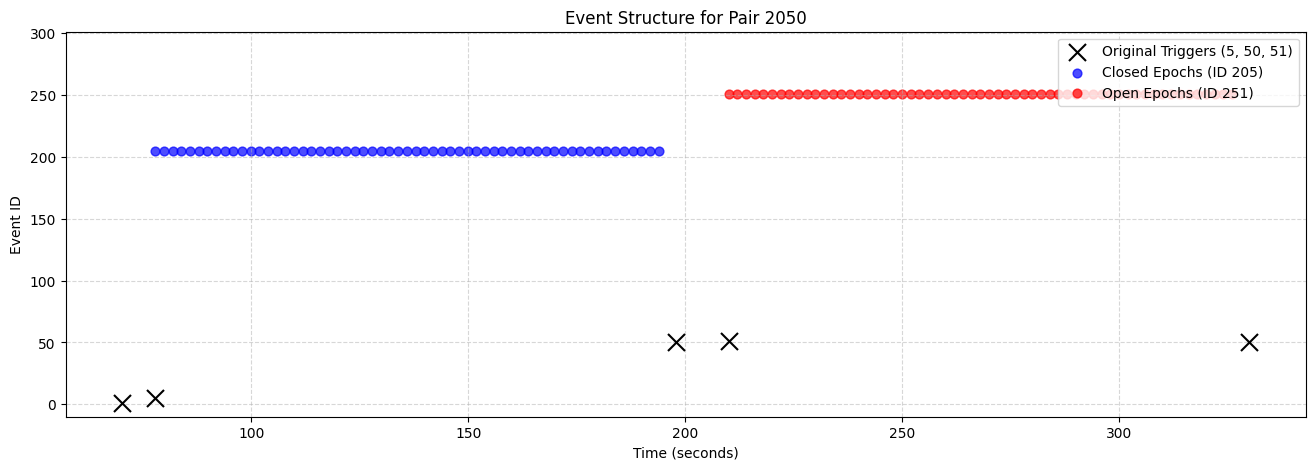


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2050 ---

--- Processing Pair 2060 ---
  Found closed baseline start (5) at sample 117934
  Found open baseline start (51) at sample 388525
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


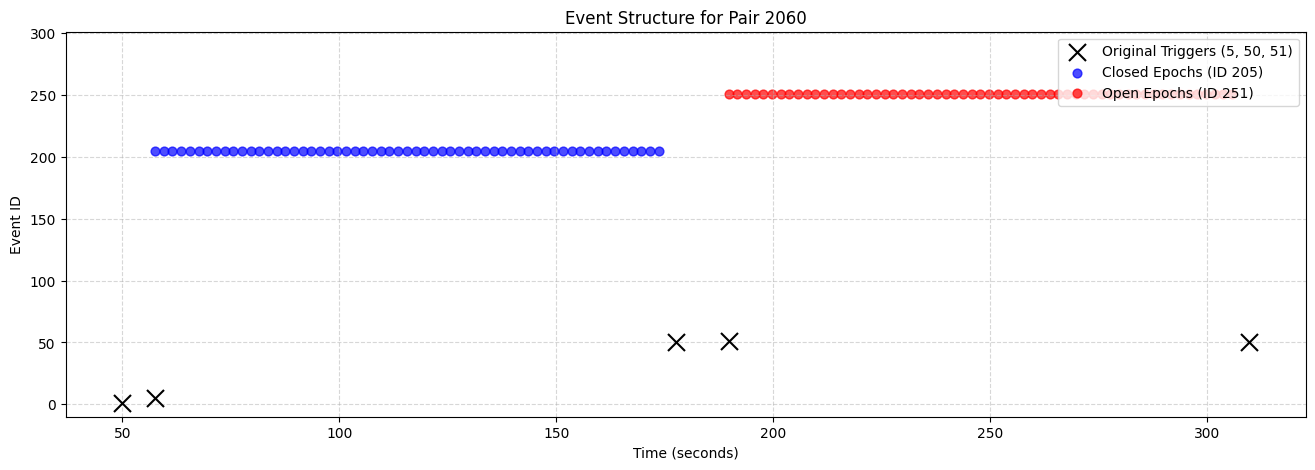


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2060 ---

--- Processing Pair 2070 ---
  Found closed baseline start (5) at sample 323222
  Found open baseline start (51) at sample 593806
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


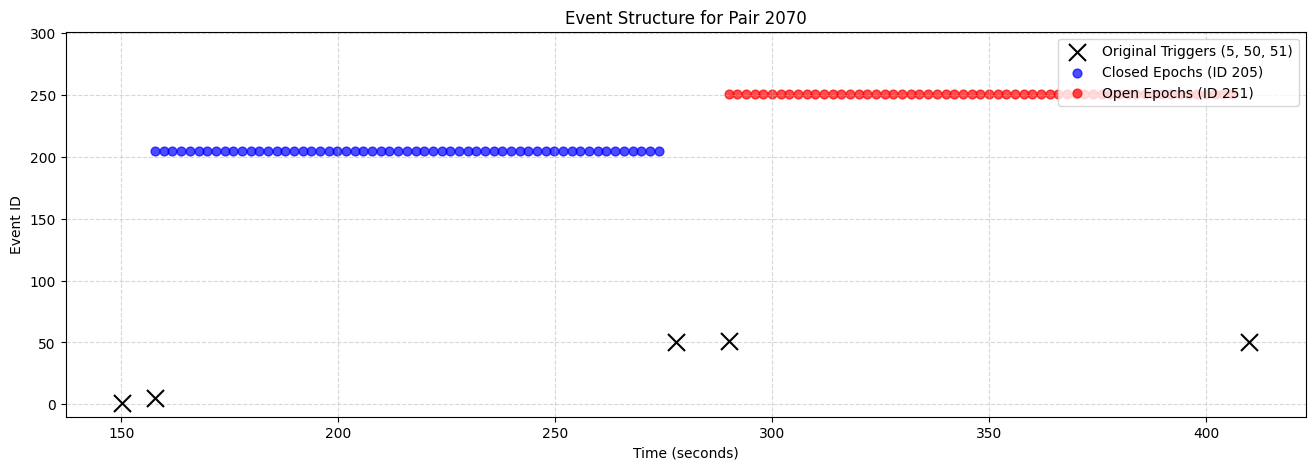


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2070 ---

--- Processing Pair 2080 ---
  Found closed baseline start (5) at sample 118473
  Found open baseline start (51) at sample 389063
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


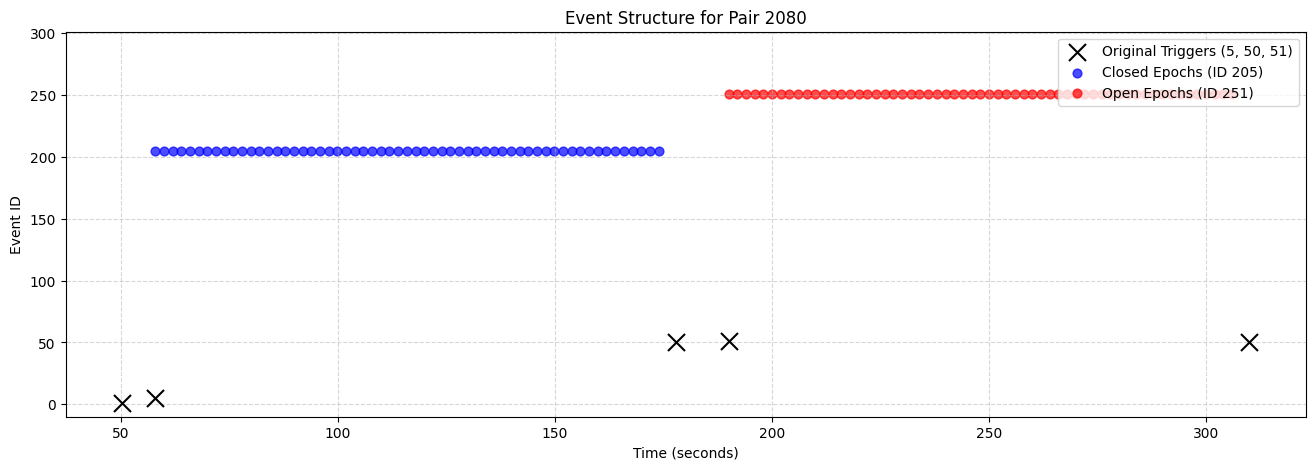


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2080 ---

--- Processing Pair 2090 ---
  Found closed baseline start (5) at sample 402039
  Found open baseline start (51) at sample 672625
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


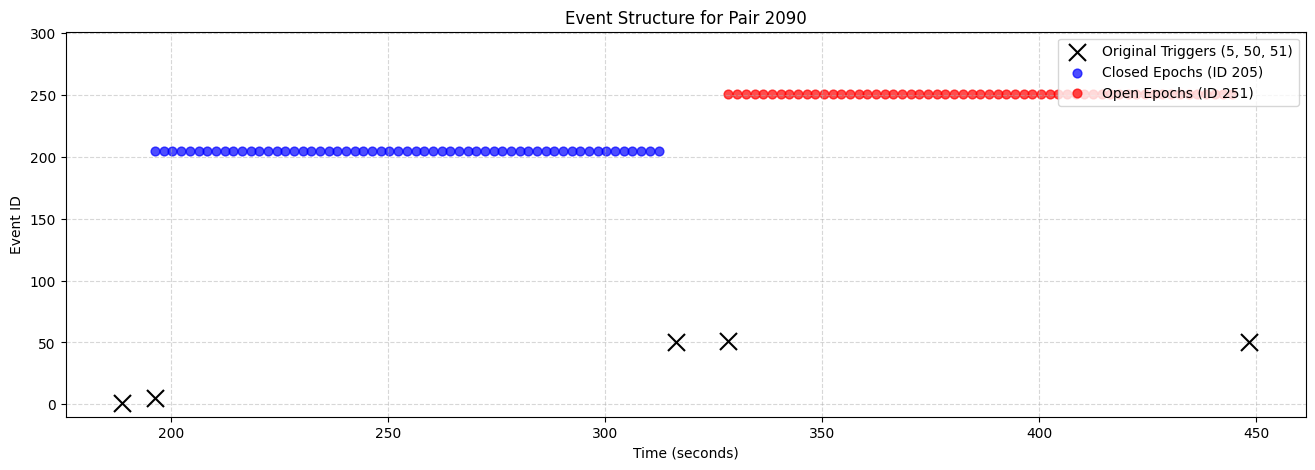


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2090 ---

--- Processing Pair 2100 ---
  Found closed baseline start (5) at sample 177971
  Found open baseline start (51) at sample 448561
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


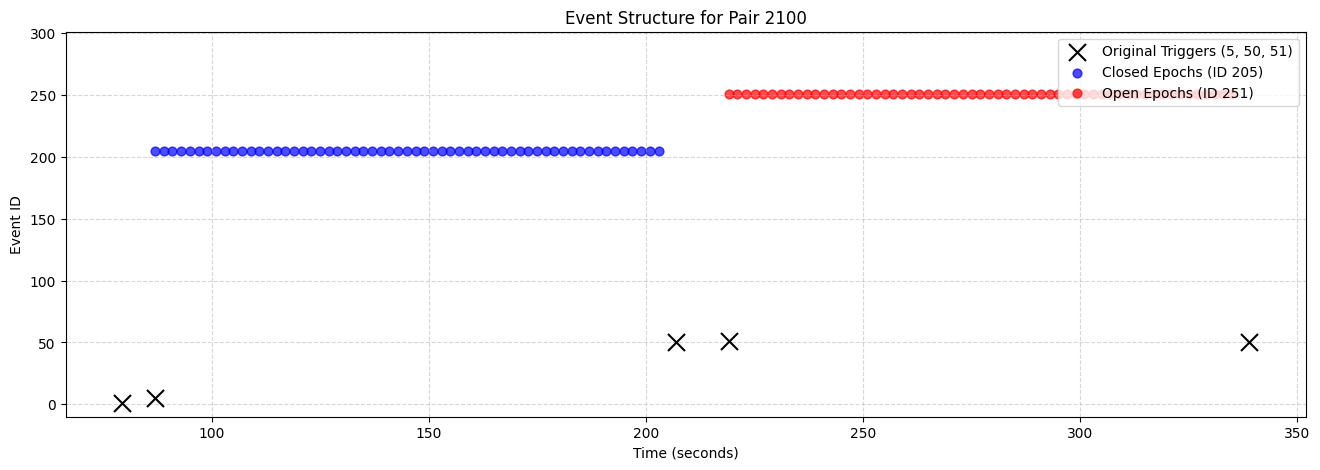


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2100 ---

--- Processing Pair 2110 ---
  Found closed baseline start (5) at sample 502984
  Found open baseline start (51) at sample 232438
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


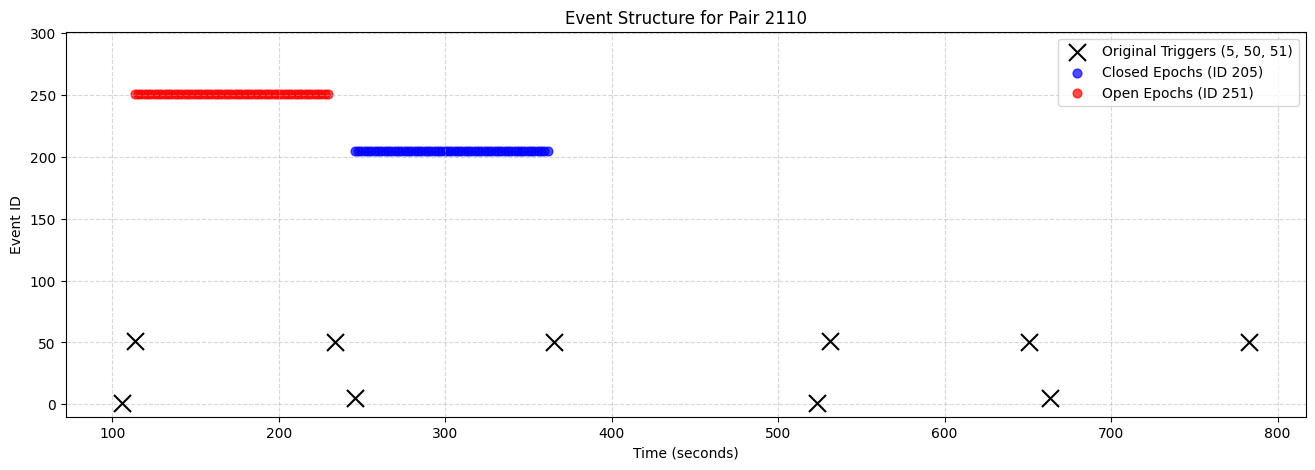


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2110 ---

--- Processing Pair 2120 ---
  Found closed baseline start (5) at sample 519126
  Found open baseline start (51) at sample 248578
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


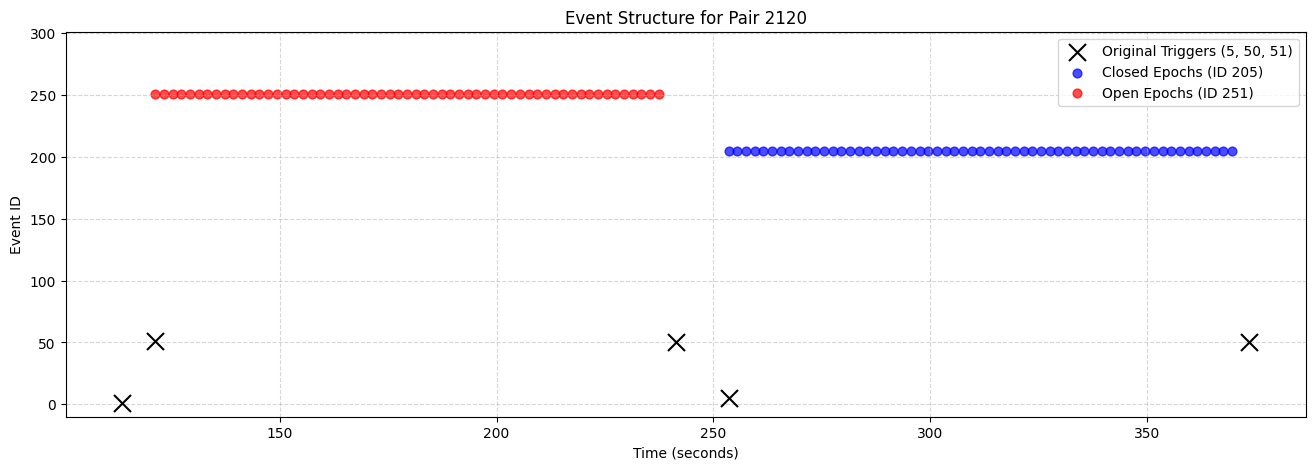


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2120 ---

--- Processing Pair 2130 ---
  Found closed baseline start (5) at sample 411703
  Found open baseline start (51) at sample 141149
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


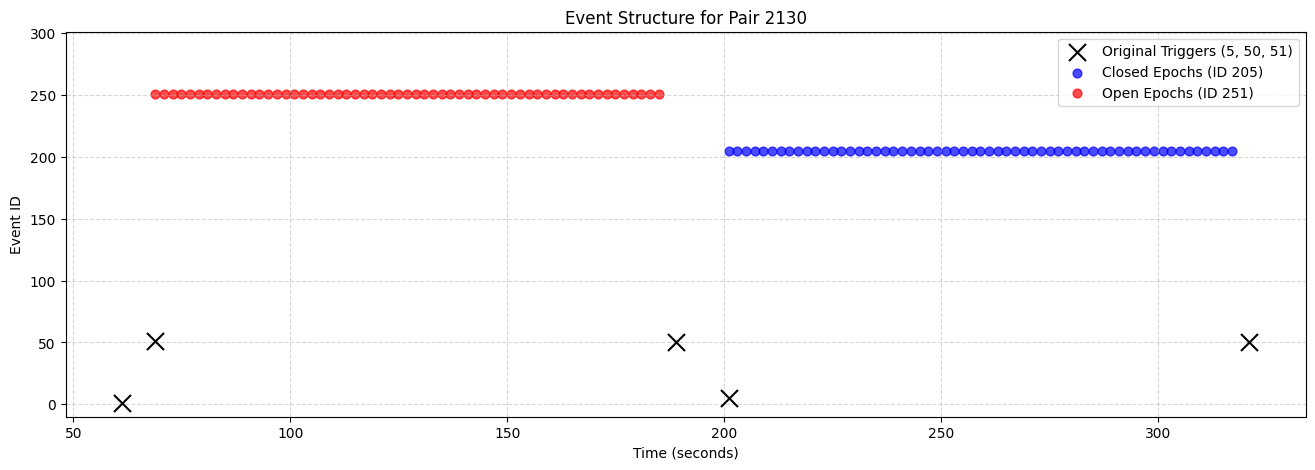


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2130 ---

--- Processing Pair 2140 ---
  Found closed baseline start (5) at sample 423203
  Found open baseline start (51) at sample 152651
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


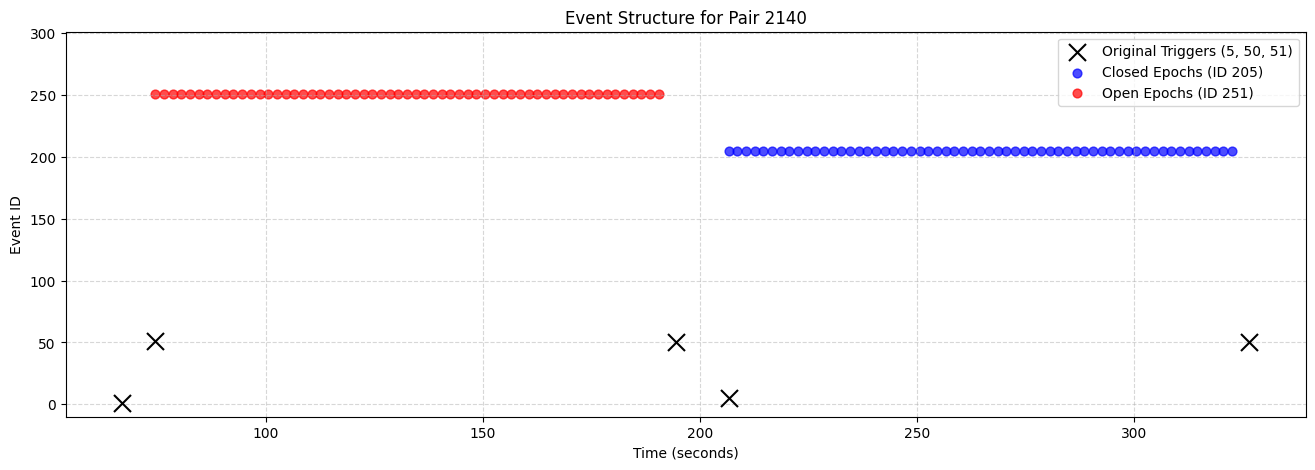


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2140 ---

--- Processing Pair 2150 ---
  Found closed baseline start (5) at sample 438223
  Found open baseline start (51) at sample 167674
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


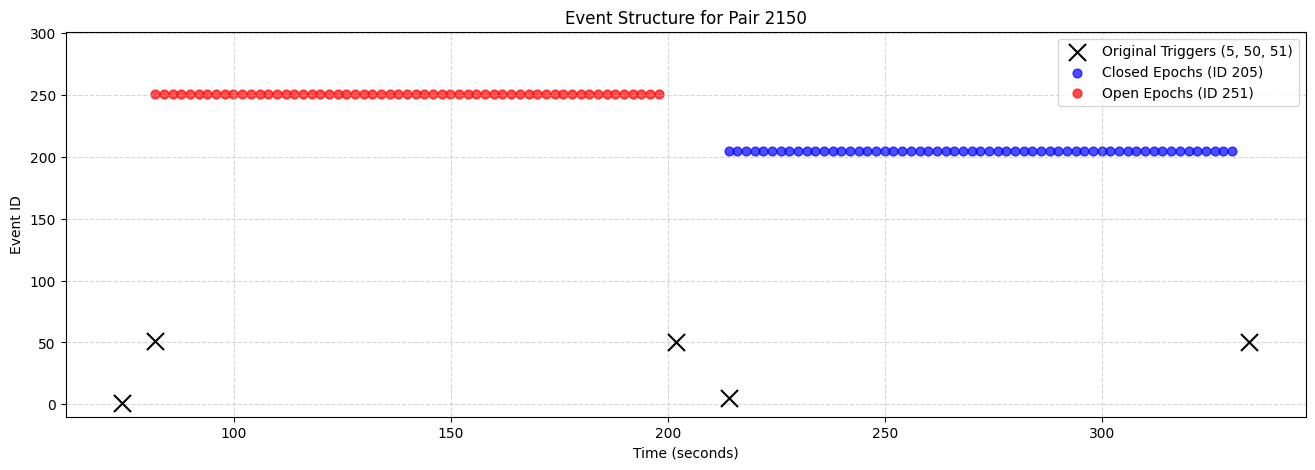


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2150 ---

--- Processing Pair 2160 ---
  Found closed baseline start (5) at sample 479074
  Found open baseline start (51) at sample 208529
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


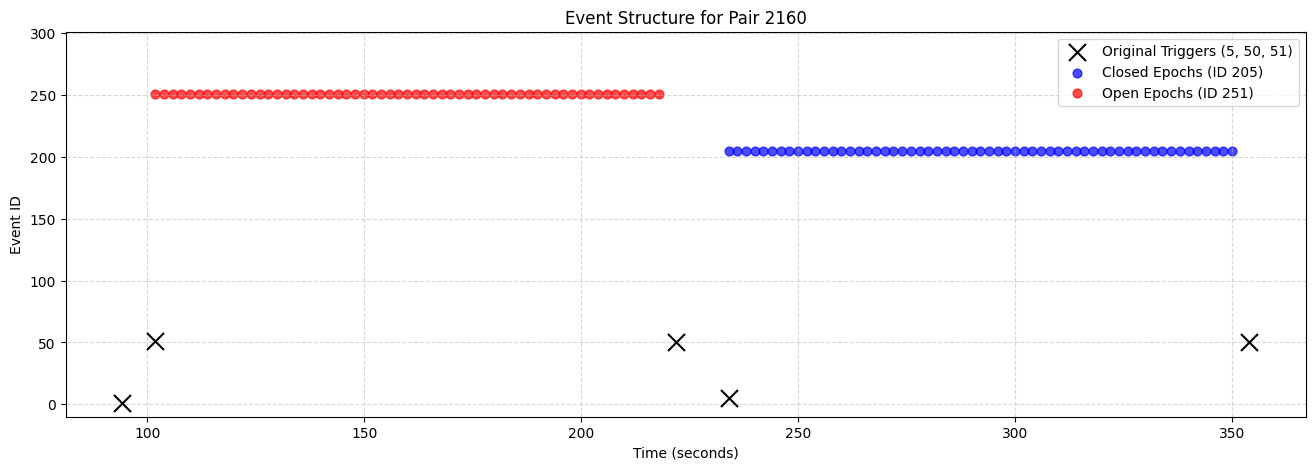


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2160 ---

--- Processing Pair 2170 ---
  Found closed baseline start (5) at sample 587362
  Found open baseline start (51) at sample 316805
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


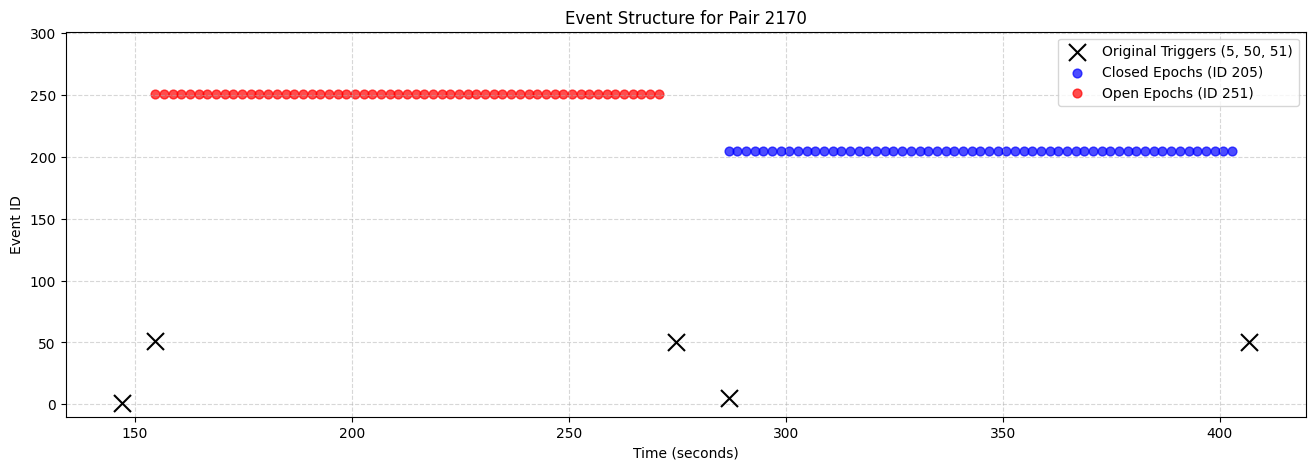


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2170 ---

--- Processing Pair 2180 ---
  Found closed baseline start (5) at sample 484322
  Found open baseline start (51) at sample 213774
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


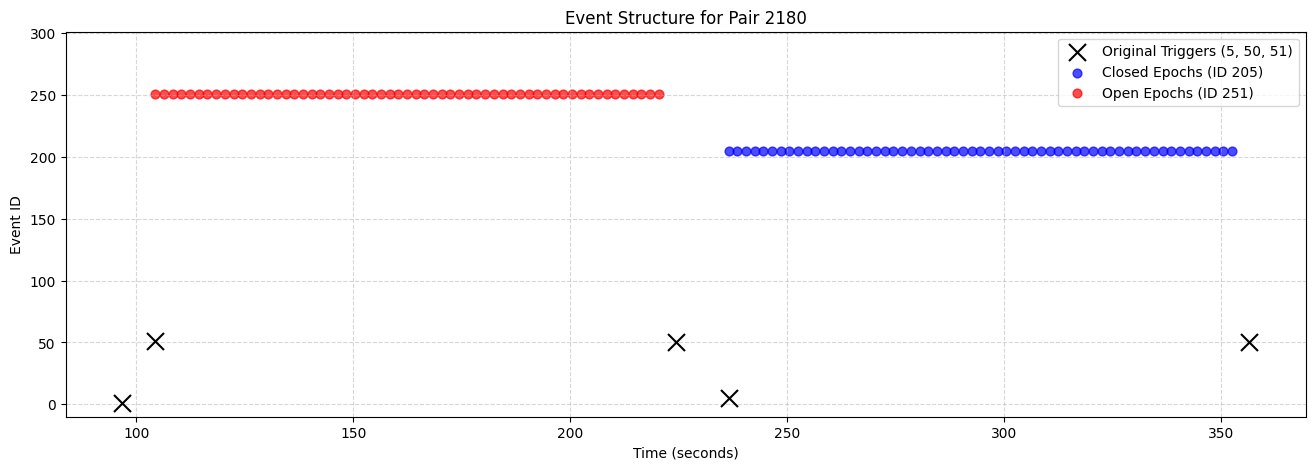


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2180 ---

--- Processing Pair 2190 ---
  Found closed baseline start (5) at sample 401340
  Found open baseline start (51) at sample 130796
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


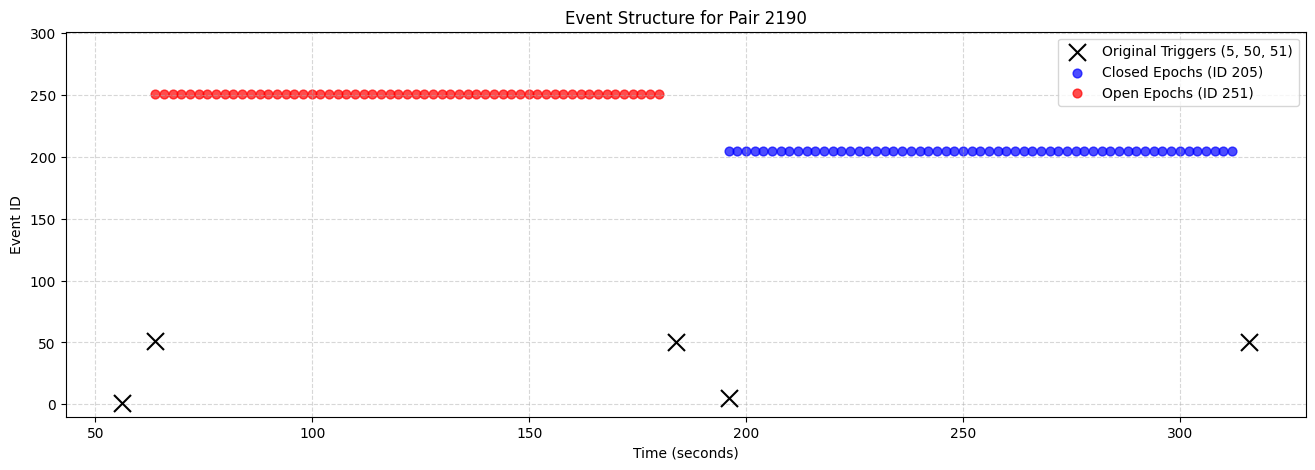


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2190 ---

--- Processing Pair 2200 ---
  Found closed baseline start (5) at sample 346745
  Found open baseline start (51) at sample 76200
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


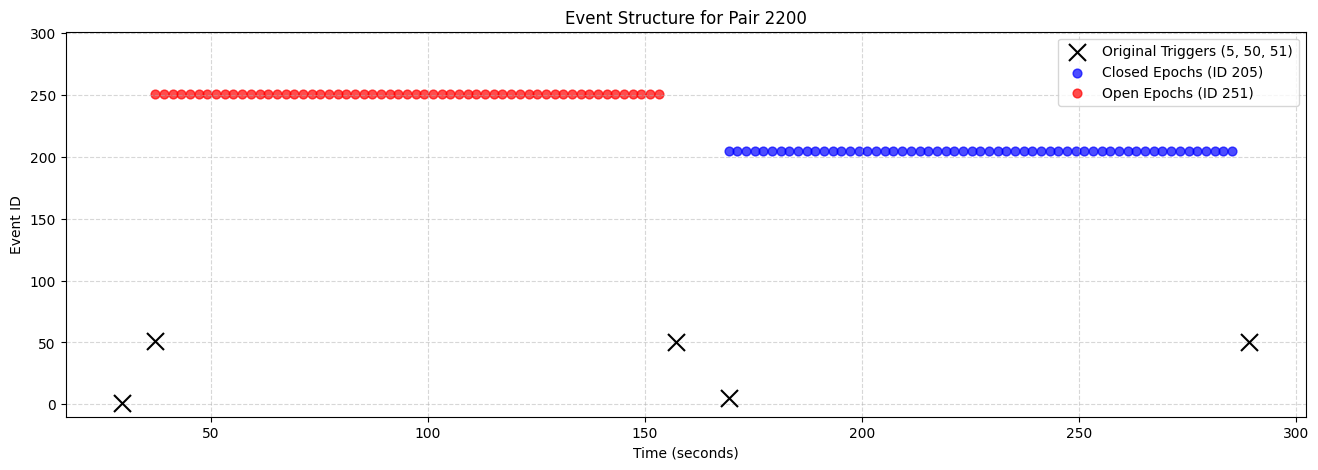


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2200 ---

--- Processing Pair 2210 ---
  Found closed baseline start (5) at sample 563006
  Found open baseline start (51) at sample 292448
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


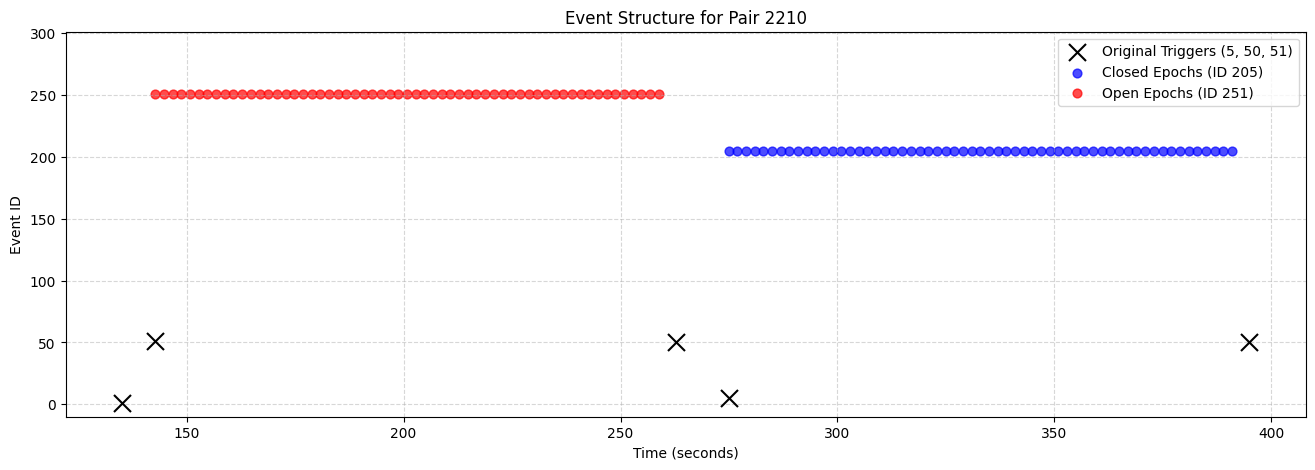


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2210 ---

--- Processing Pair 2220 ---
  Found closed baseline start (5) at sample 349919
  Found open baseline start (51) at sample 79371
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


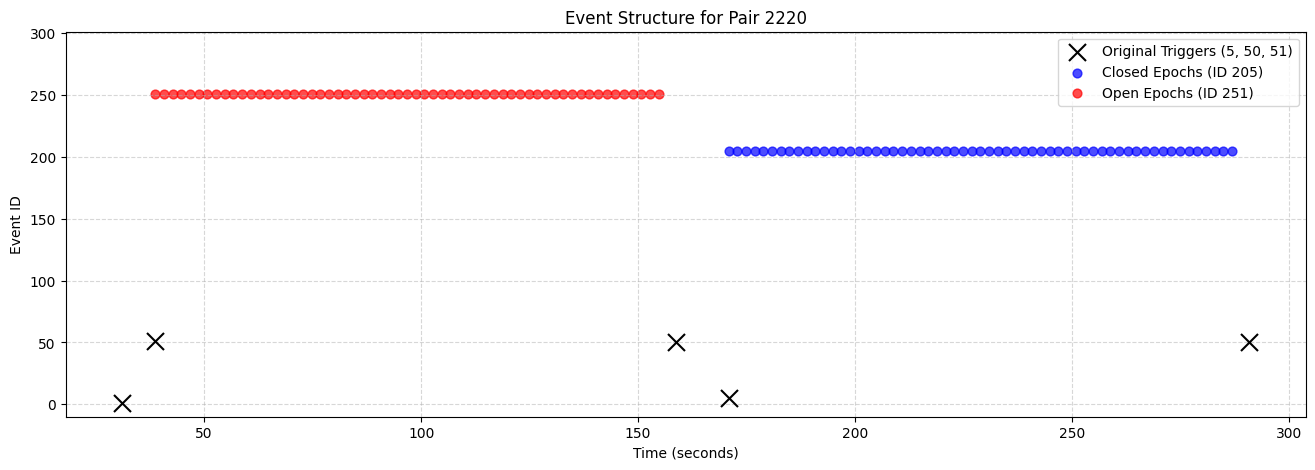


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2220 ---

--- Processing Pair 2230 ---
  Found closed baseline start (5) at sample 442608
  Found open baseline start (51) at sample 172062
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


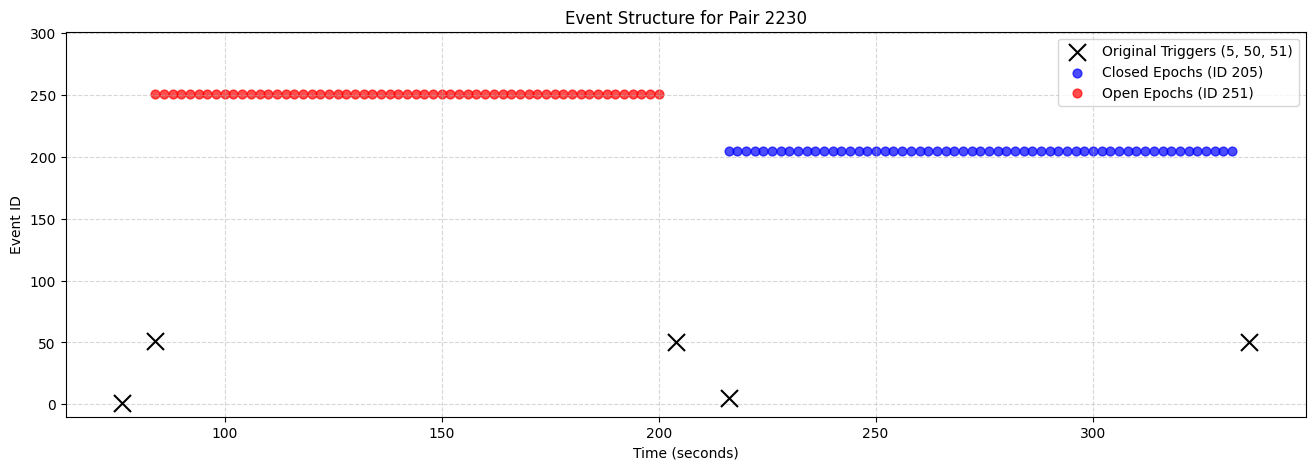


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2230 ---

--- Processing Pair 2240 ---
  Found closed baseline start (5) at sample 390722
  Found open baseline start (51) at sample 120171
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


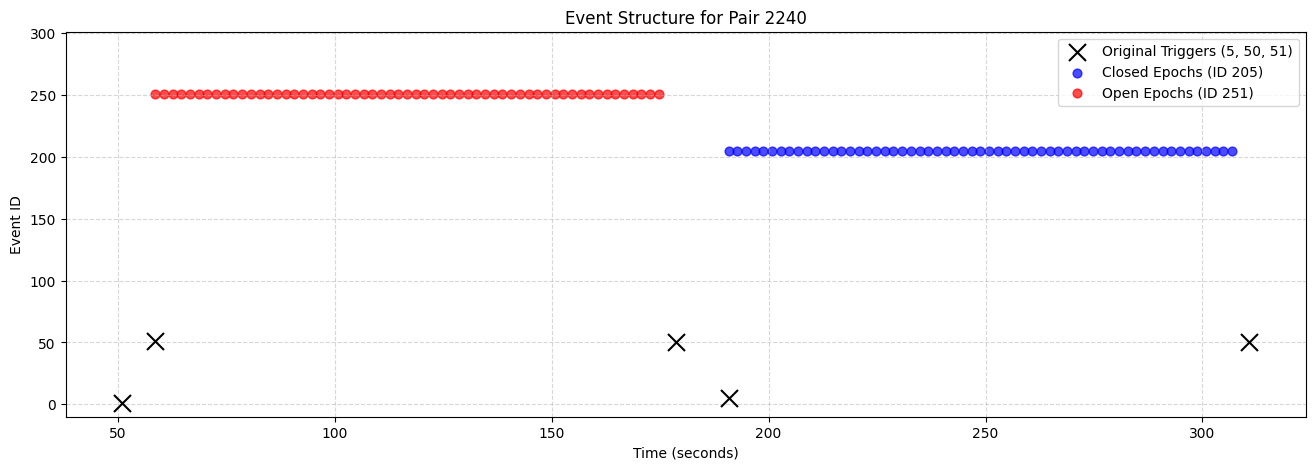


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2240 ---

--- Processing Pair 2250 ---
  Found closed baseline start (5) at sample 362956
  Found open baseline start (51) at sample 92401
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


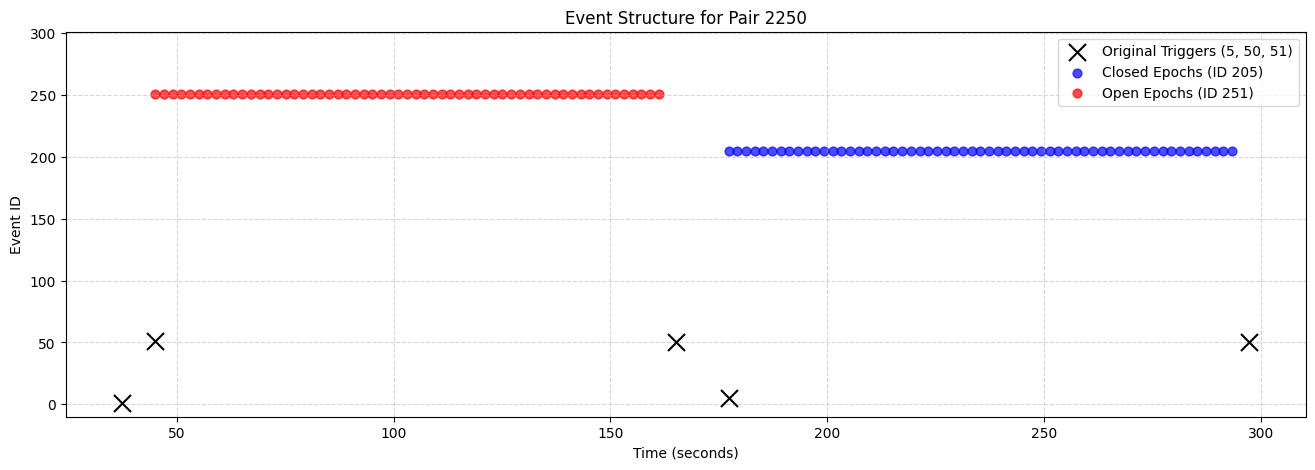


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2250 ---

--- Processing Pair 2260 ---
  Found closed baseline start (5) at sample 349194
  Found open baseline start (51) at sample 78644
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


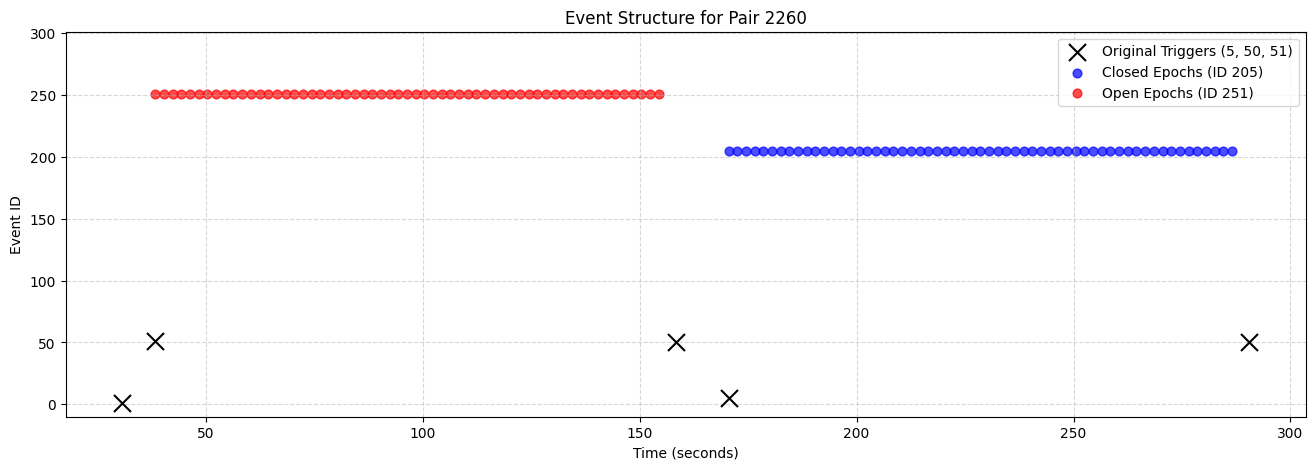


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2260 ---

--- Processing Pair 2270 ---
  Found closed baseline start (5) at sample 375197
  Found open baseline start (51) at sample 104642
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


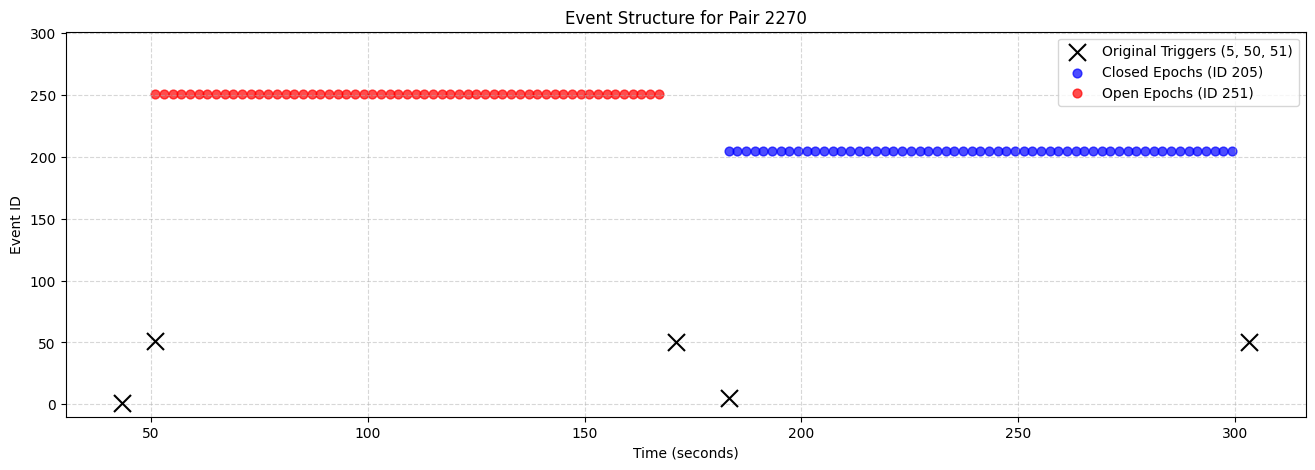


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2270 ---

--- Processing Pair 2280 ---
  Found closed baseline start (5) at sample 369661
  Found open baseline start (51) at sample 99113
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


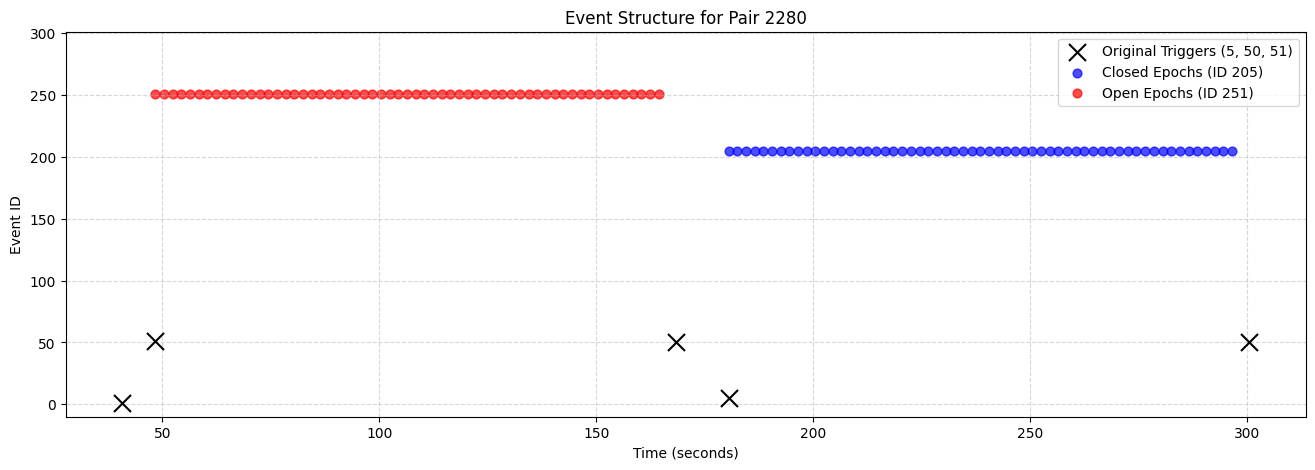


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2280 ---

--- Processing Pair 2290 ---
  Found closed baseline start (5) at sample 328059
  Found open baseline start (51) at sample 57508
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


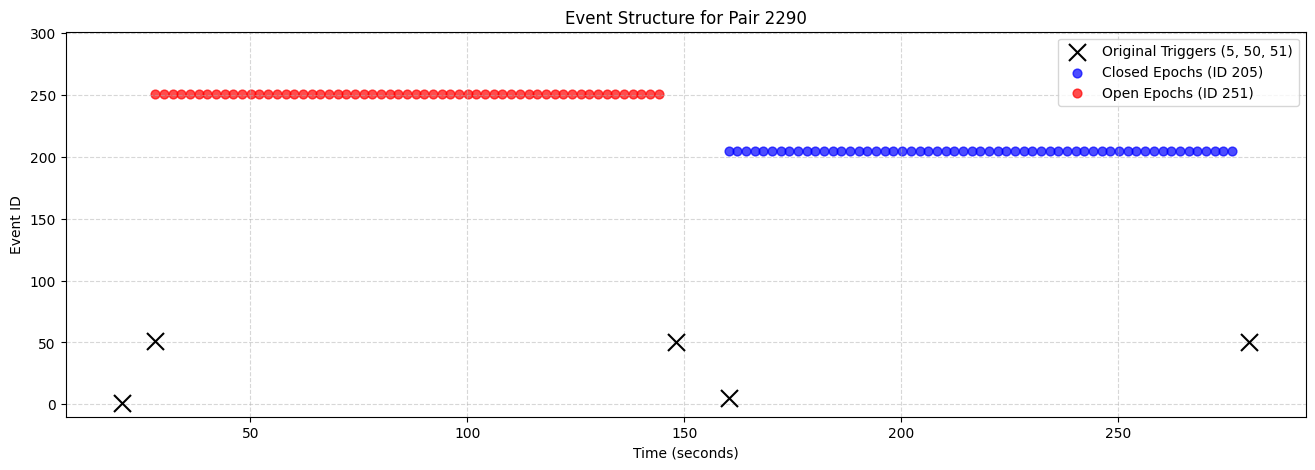


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2290 ---

--- Processing Pair 2300 ---
  Found closed baseline start (5) at sample 419793
  Found open baseline start (51) at sample 149244
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


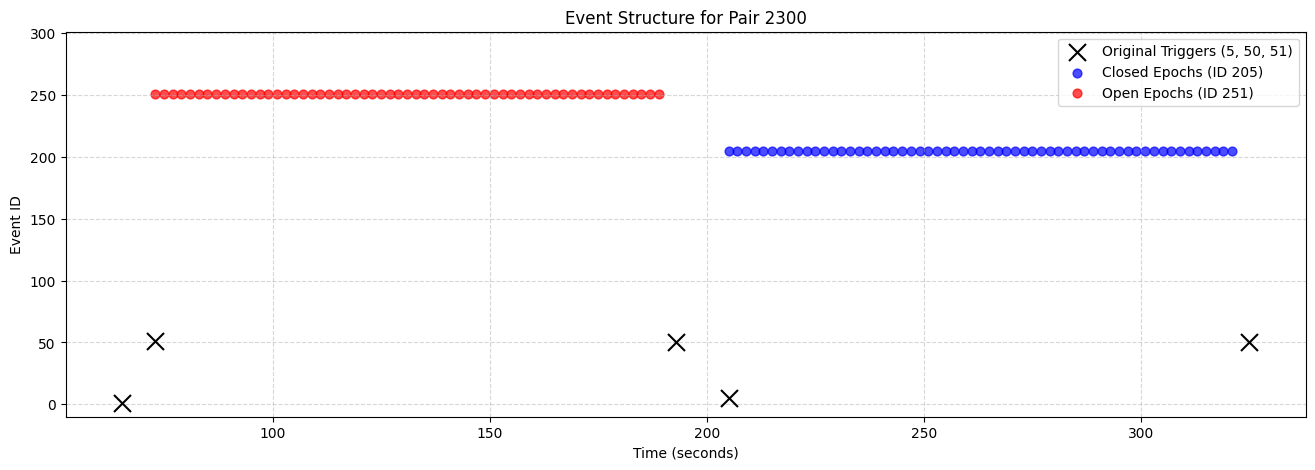


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2300 ---

--- Processing Pair 2310 ---
  Found closed baseline start (5) at sample 372814
  Found open baseline start (51) at sample 102261
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


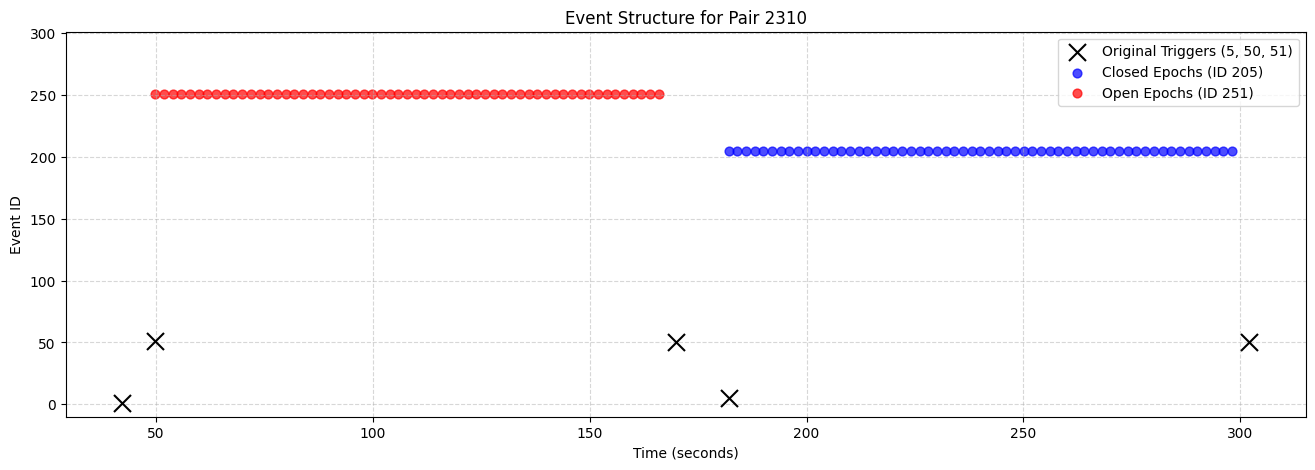


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2310 ---

--- Processing Pair 2320 ---
  Found closed baseline start (5) at sample 444963
  Found open baseline start (51) at sample 174406
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


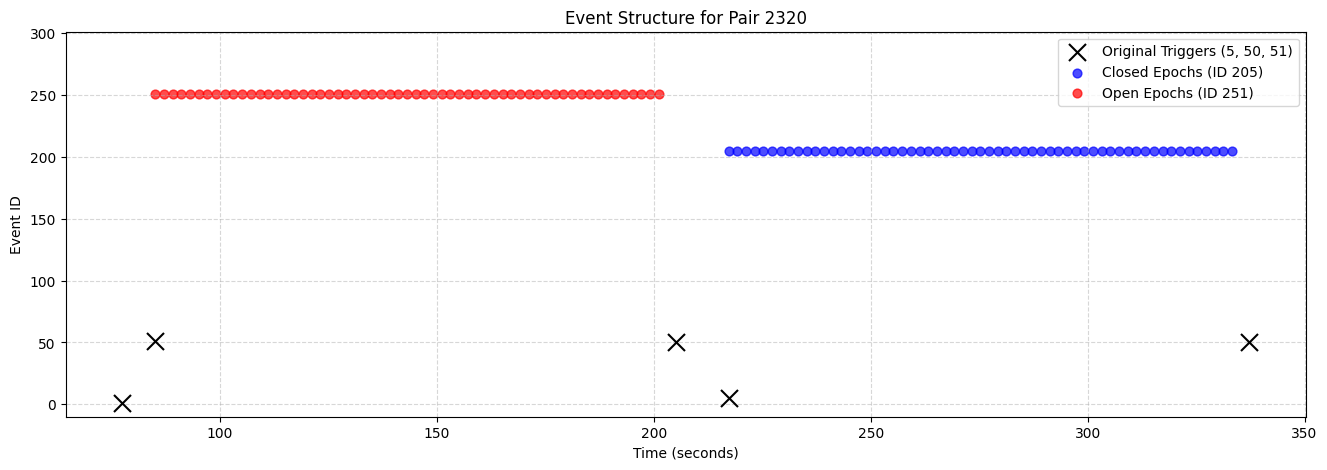


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2320 ---

--- Processing Pair 2330 ---
  Found closed baseline start (5) at sample 349655
  Found open baseline start (51) at sample 79104
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


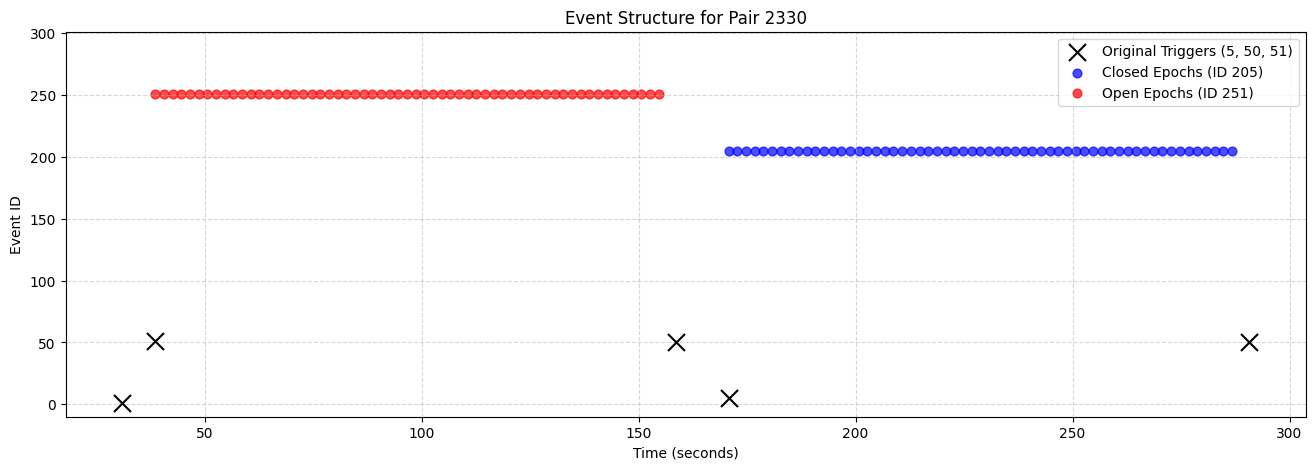


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2330 ---

--- Processing Pair 2340 ---
  Found closed baseline start (5) at sample 348464
  Found open baseline start (51) at sample 77916
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


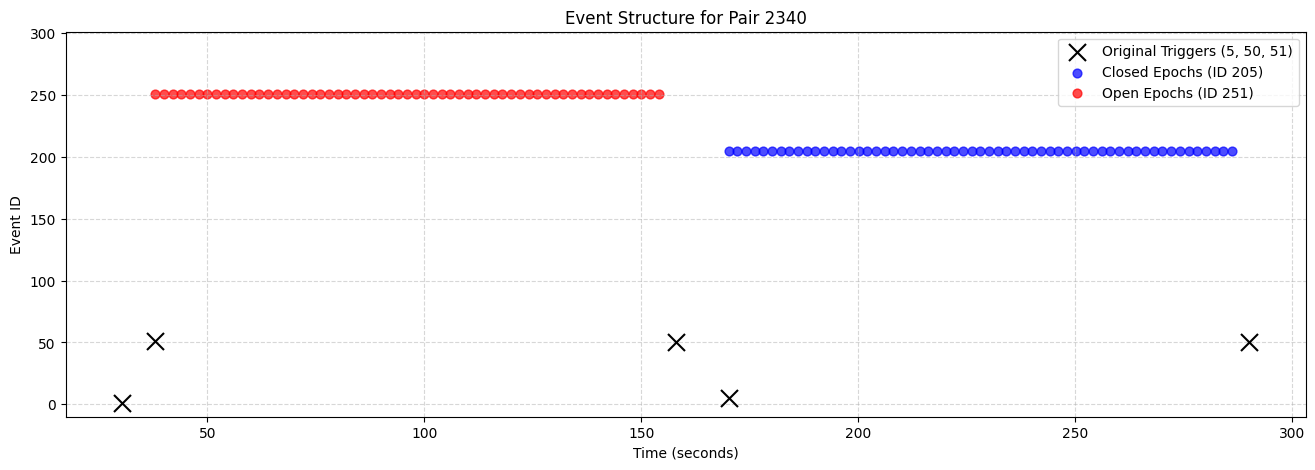


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2340 ---

--- Processing Pair 2350 ---
  Found closed baseline start (5) at sample 446036
  Found open baseline start (51) at sample 175493
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


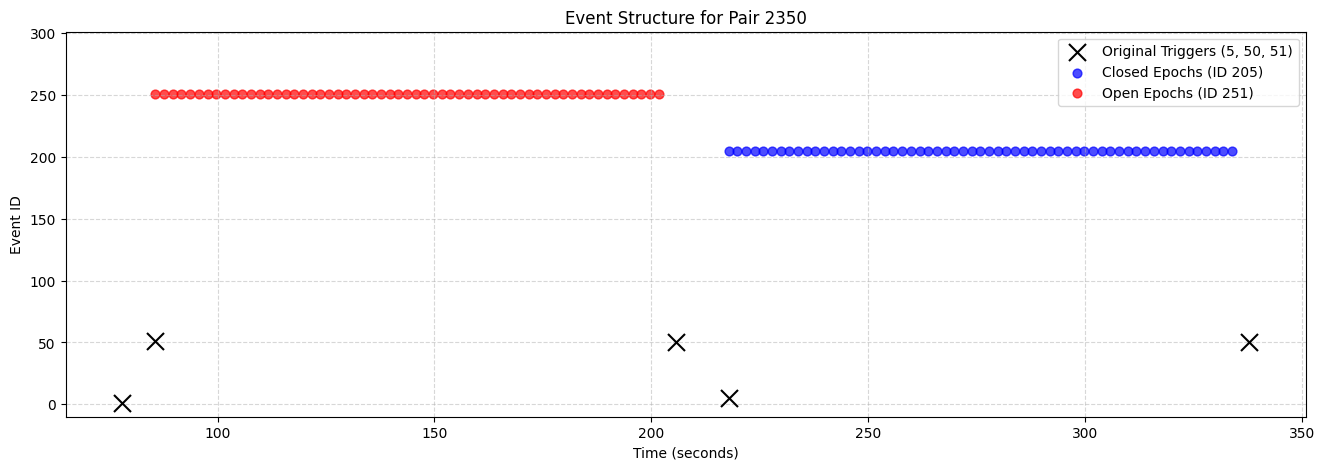


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2350 ---

--- Processing Pair 2360 ---
  Found closed baseline start (5) at sample 118174
  Found open baseline start (51) at sample 388721
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


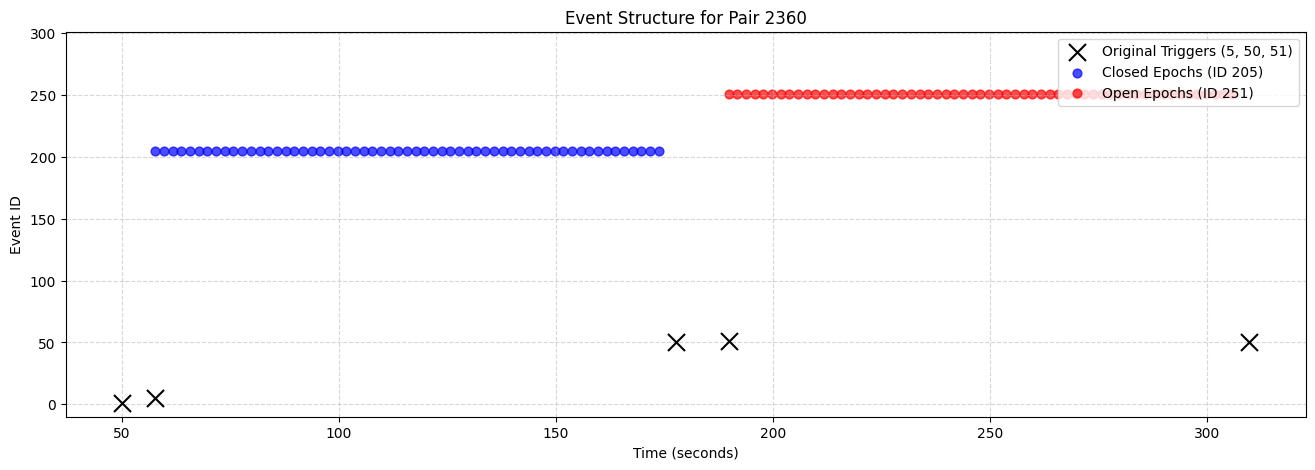


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2360 ---

--- Processing Pair 2370 ---
  Found closed baseline start (5) at sample 109010
  Found open baseline start (51) at sample 379573
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


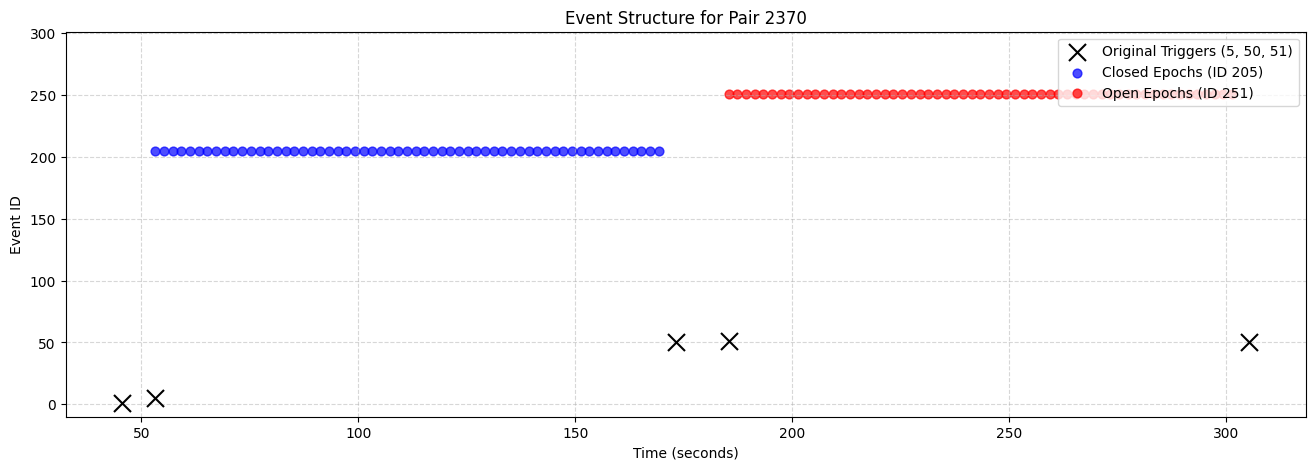


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2370 ---

--- Processing Pair 2380 ---
  Found closed baseline start (5) at sample 192049
  Found open baseline start (51) at sample 462598
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


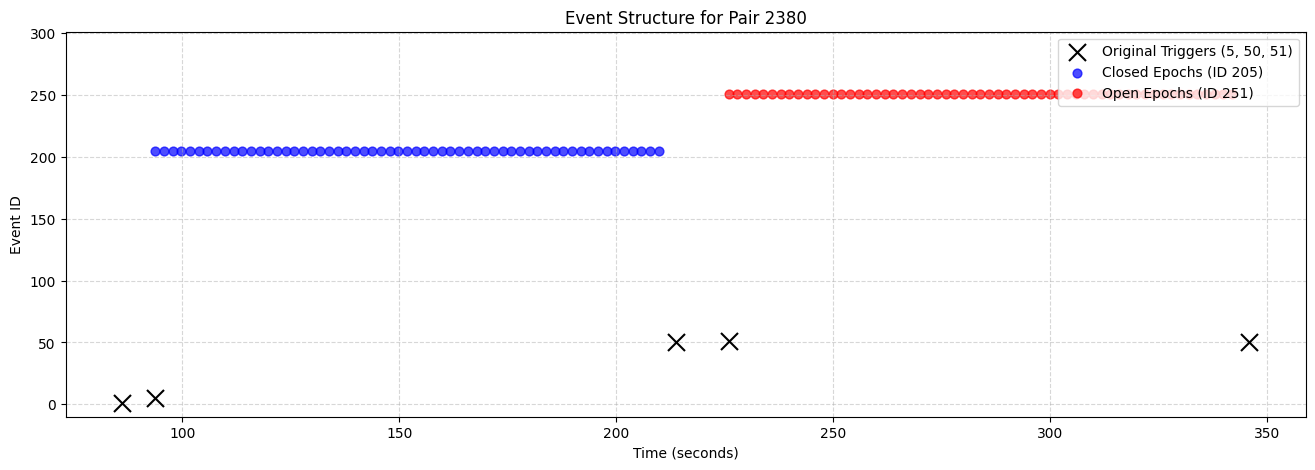


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2380 ---

--- Processing Pair 2390 ---
  Found closed baseline start (5) at sample 81028
  Found open baseline start (51) at sample 351577
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


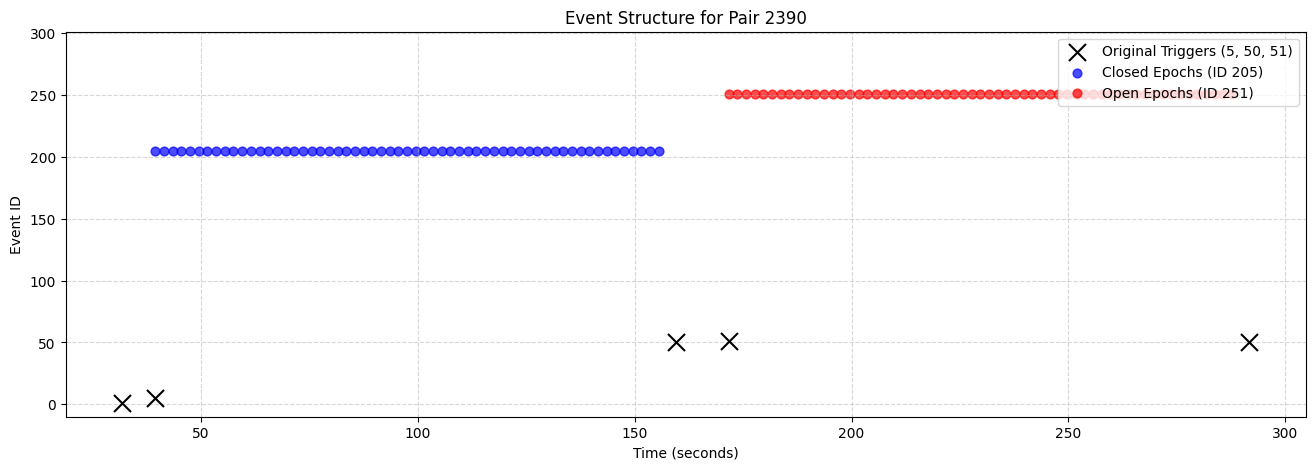


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2390 ---

--- Processing Pair 2410 ---
  Found closed baseline start (5) at sample 139255
  Found open baseline start (51) at sample 409800
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


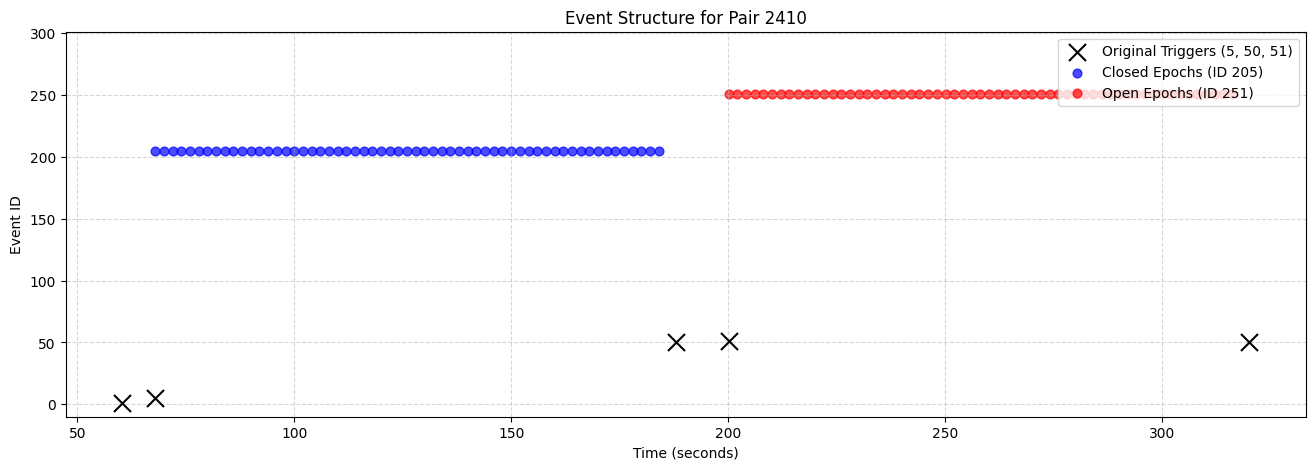


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2410 ---

--- Processing Pair 2420 ---
  Found closed baseline start (5) at sample 51575
  Found open baseline start (51) at sample 322126
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


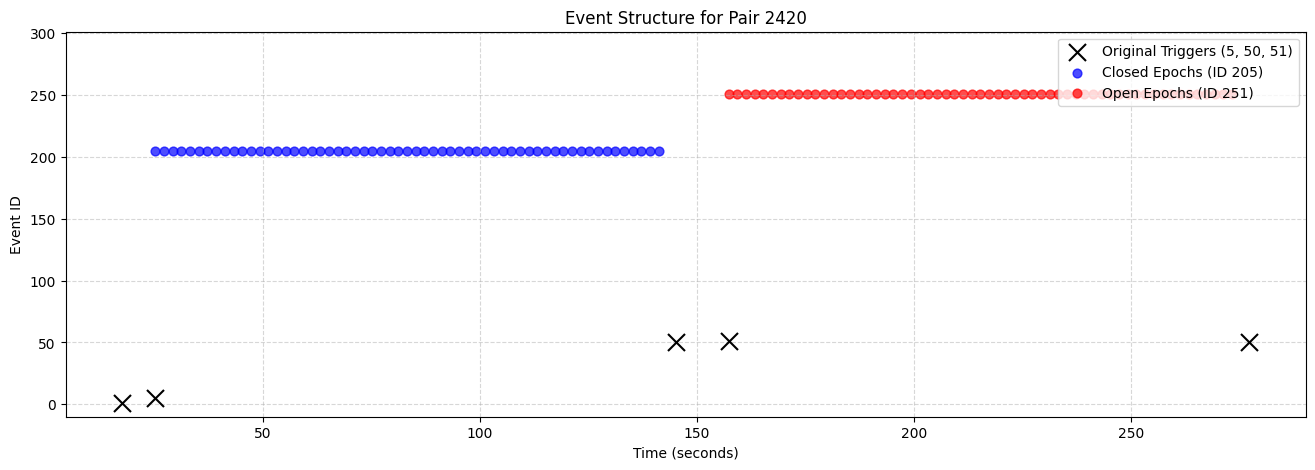


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2420 ---

--- Processing Pair 2430 ---
  Found closed baseline start (5) at sample 379337
  Found open baseline start (51) at sample 649885
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


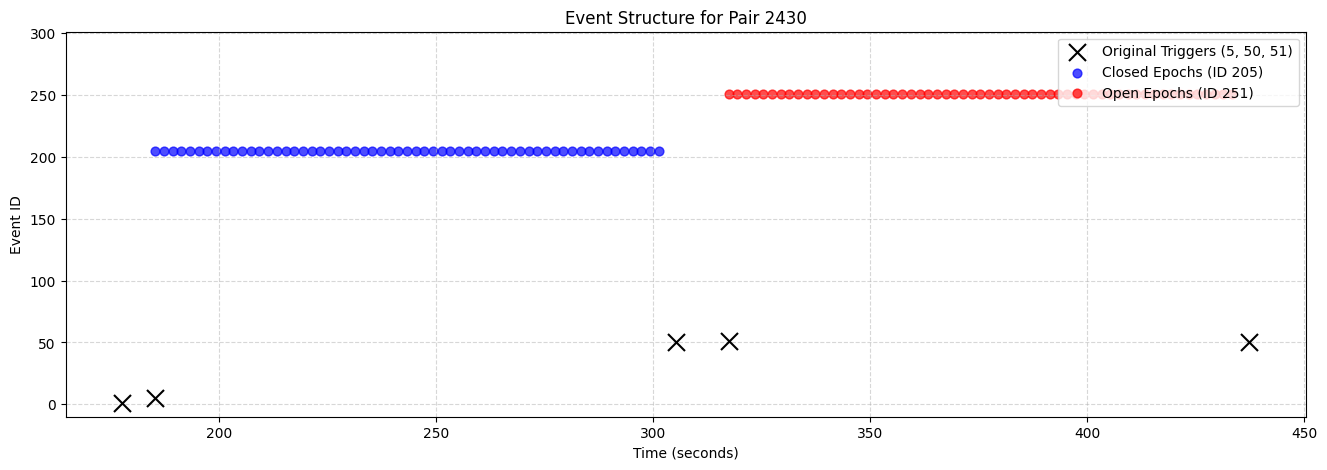


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2430 ---

--- Processing Pair 2440 ---
  Found closed baseline start (5) at sample 130499
  Found open baseline start (51) at sample 401038
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


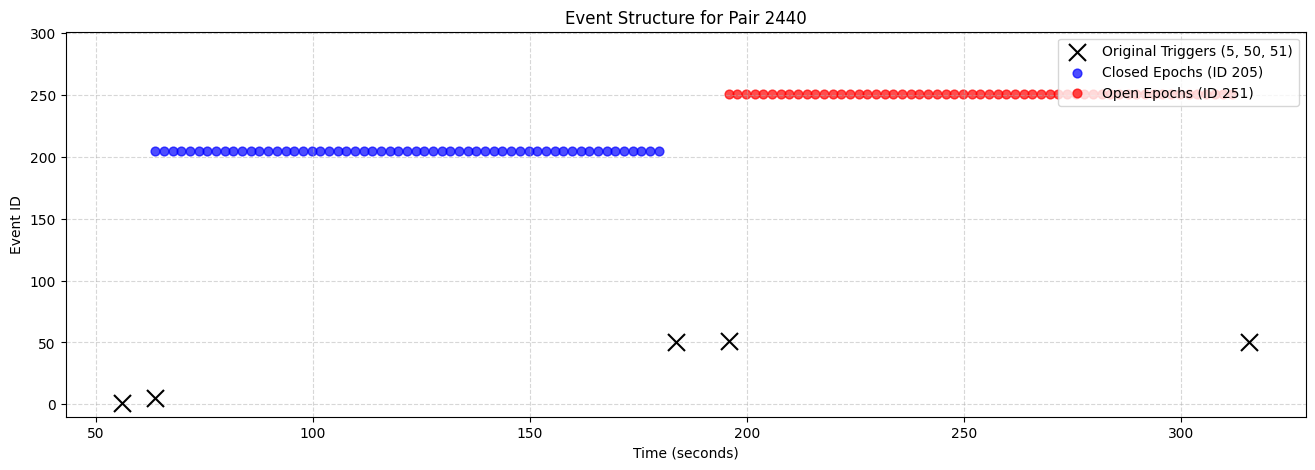


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2440 ---

--- Processing Pair 2450 ---
  Found closed baseline start (5) at sample 225205
  Found open baseline start (51) at sample 495755
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


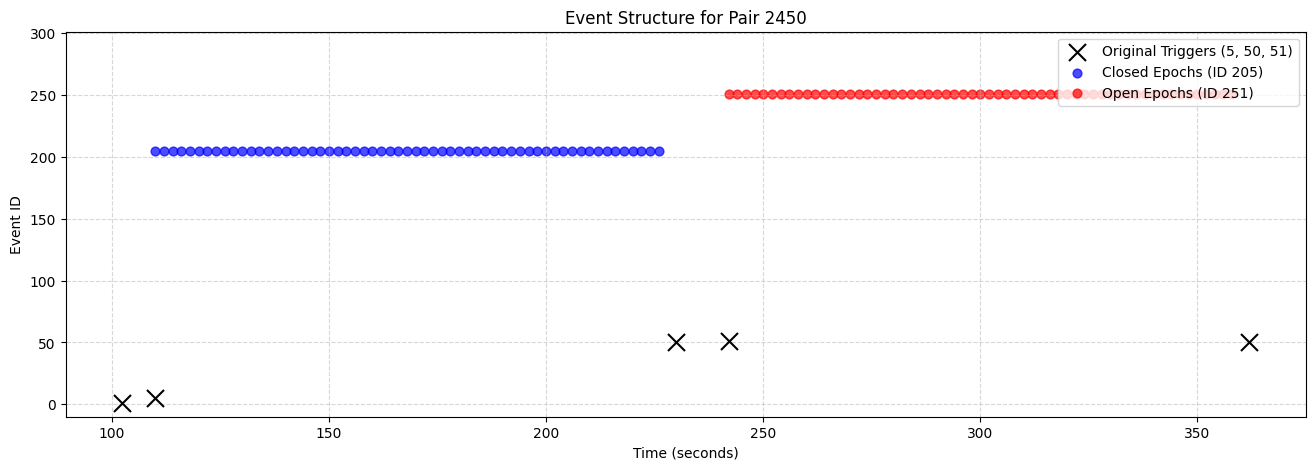


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2450 ---

--- Processing Pair 2460 ---
  Found closed baseline start (5) at sample 56782
  Found open baseline start (51) at sample 327332
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


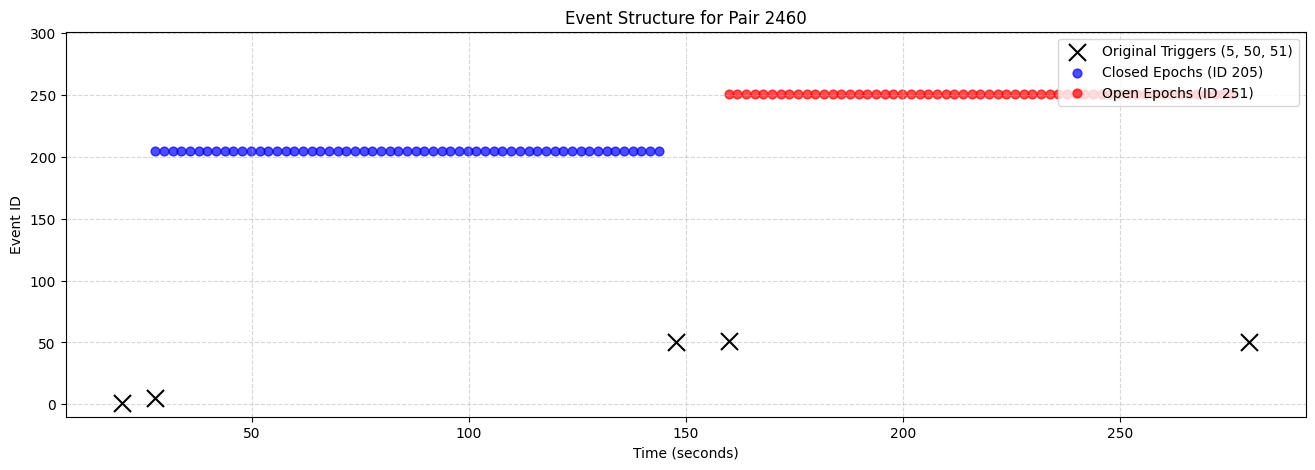


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2460 ---

--- Processing Pair 2470 ---
  Found closed baseline start (5) at sample 48542
  Found open baseline start (51) at sample 319083
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


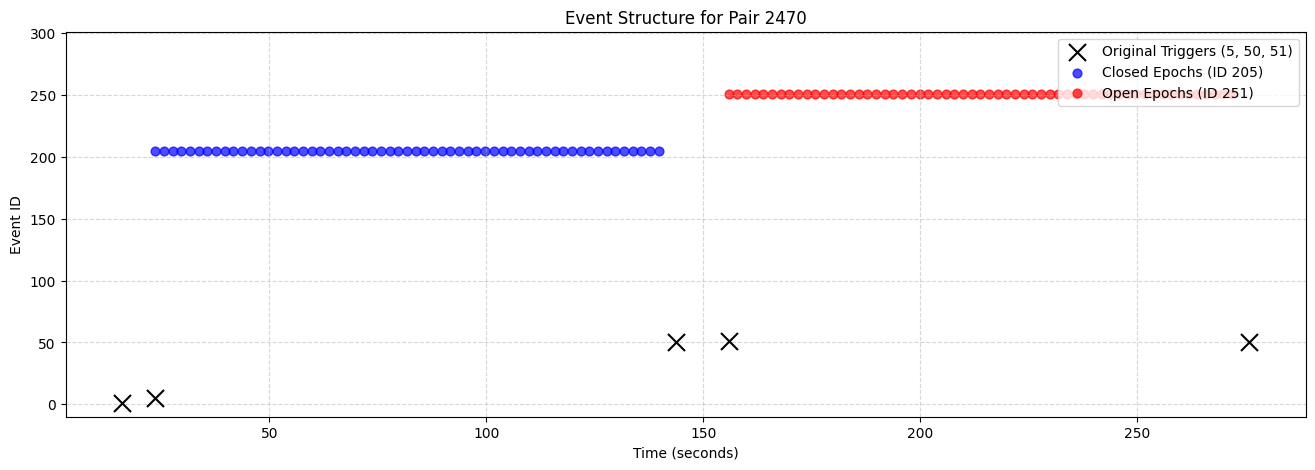


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2470 ---

--- Processing Pair 2480 ---
  Found closed baseline start (5) at sample 49400
  Found open baseline start (51) at sample 319956
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


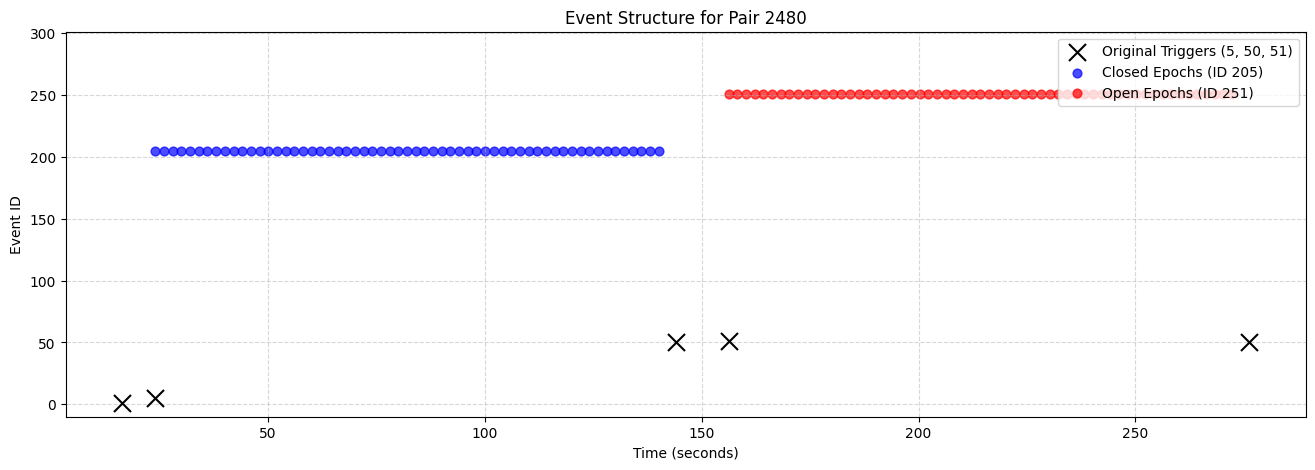


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2480 ---

--- Processing Pair 2490 ---
  Found closed baseline start (5) at sample 168273
  Found open baseline start (51) at sample 438823
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


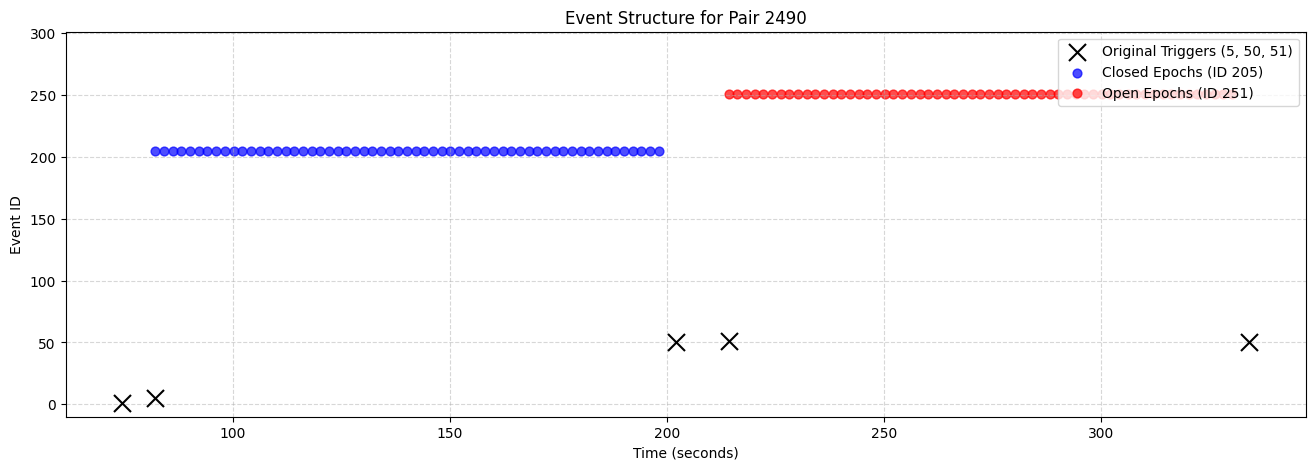


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2490 ---

--- Processing Pair 2500 ---
  Found closed baseline start (5) at sample 53737
  Found open baseline start (51) at sample 324284
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


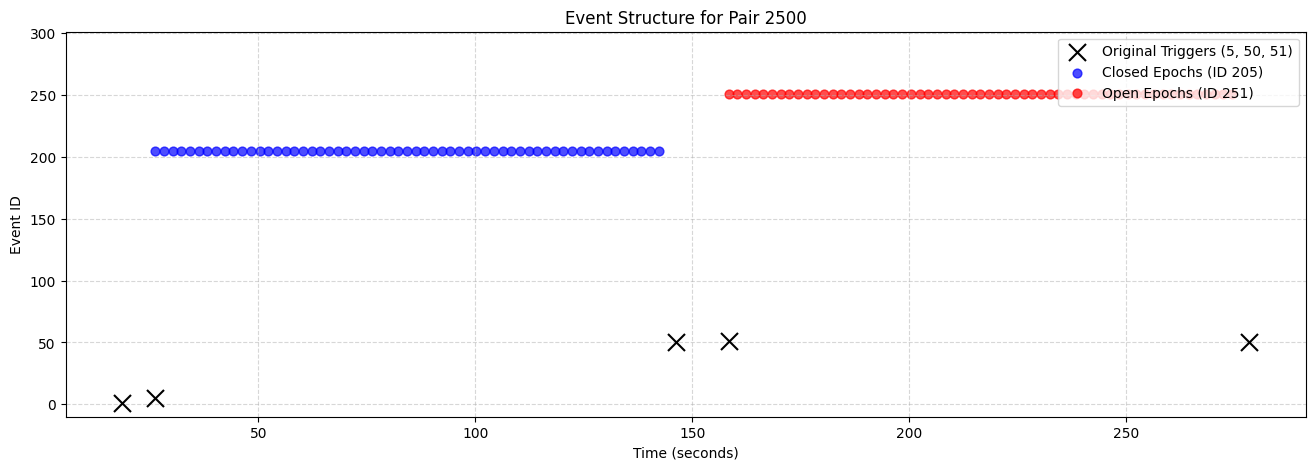


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2500 ---

--- Processing Pair 2510 ---
  Found closed baseline start (5) at sample 144636
  Found open baseline start (51) at sample 415181
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


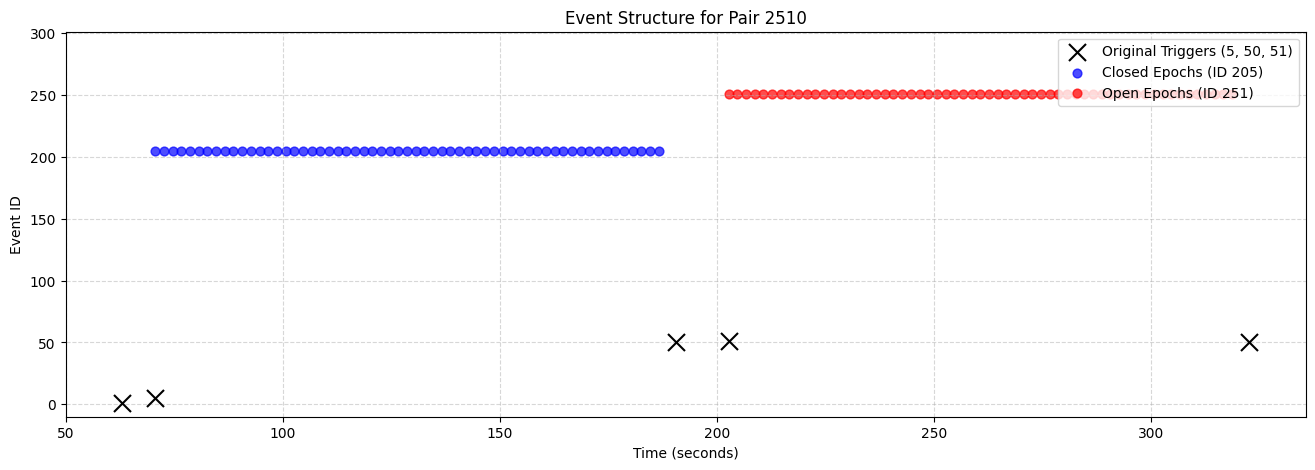


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2510 ---

--- Processing Pair 2520 ---
  Found closed baseline start (5) at sample 91655
  Found open baseline start (51) at sample 362198
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


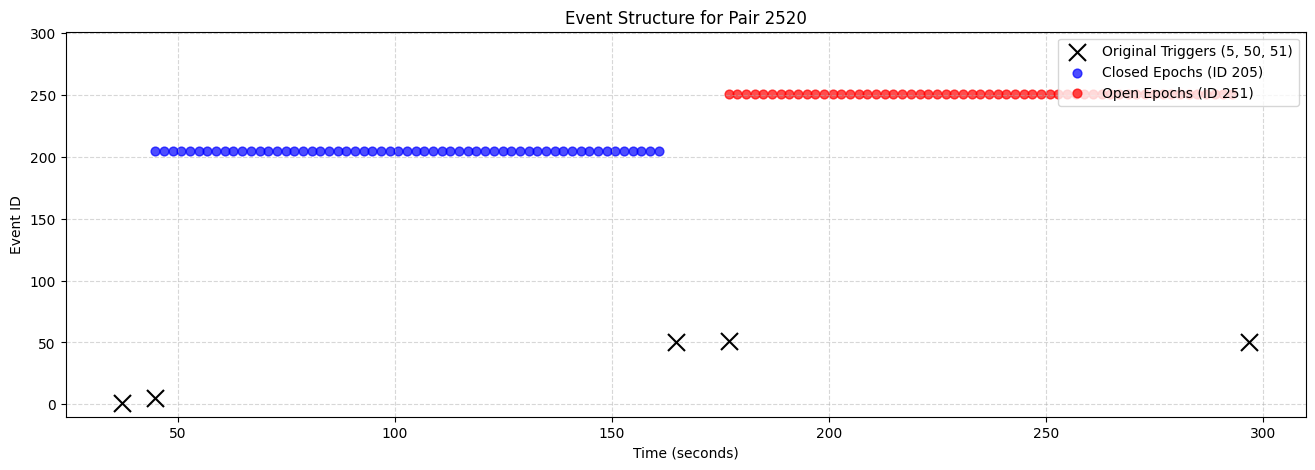


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2520 ---

--- Processing Pair 2530 ---
  Found closed baseline start (5) at sample 164189
  Found open baseline start (51) at sample 434740
  Created 59 events for 'closed_baseline' (ID 205)
  Created 59 events for 'open_baseline' (ID 251)


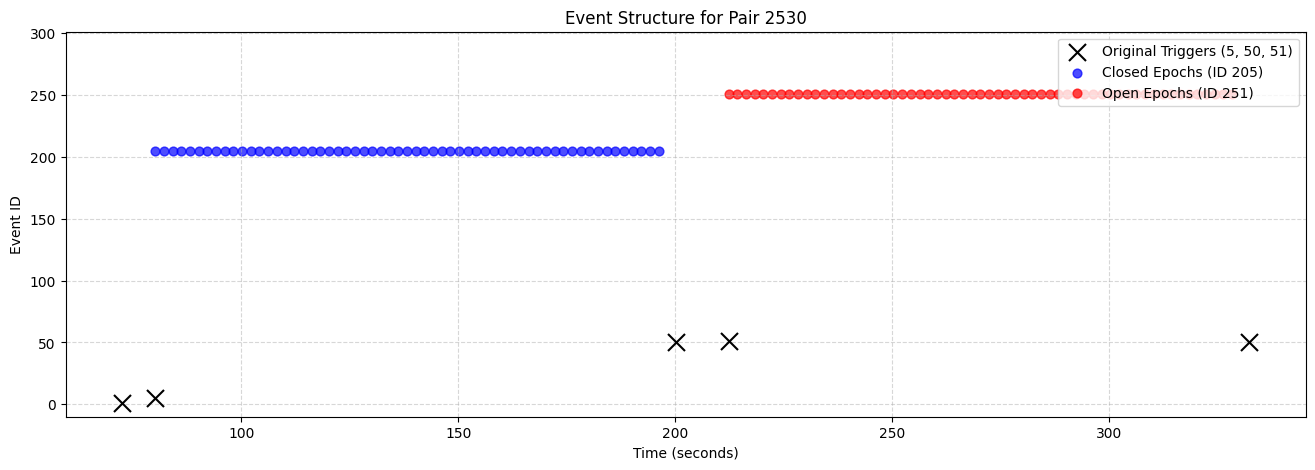


  Successfully created Epochs object for subject A:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
  Successfully created Epochs object for subject B:
<Epochs | 118 events (all good), 0 – 4 s (baseline off), ~509.0 MiB, data loaded,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>
--- Finished Pair 2530 ---

=== All pairs processed. ===


In [2]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

# Define the base directory for your data
# --- !!! UPDATE THIS PATH !!! ---
base_data_folder = "/Volumes/T9/Circling_dataset/ICA"

all_pairs = [2010, 2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100, 2110, 2120, 2130, 2140, 2150, 2160, 2170, 2180, 2190, 2200,
             2210, 2220, 2230, 2240, 2250, 2260, 2270, 2280, 2290, 2300, 2310, 2320, 2330, 2340, 2350, 2360, 2370, 2380, 2390,
             2410, 2420, 2430, 2440, 2450, 2460, 2470, 2480, 2490, 2500, 2510, 2520, 2530]

# all_pairs = [2010, 2020, 2130]

# Define new event IDs for clarity
CLOSED_EPOCH_ID = 205
OPEN_EPOCH_ID = 251

# Define epoching parameters
EPOCH_LEN_SEC = 4.0
STEP_SEC = 2.0  # (for 50% overlap of a 4s epoch)
BASELINE_LEN_SEC = 120.0

print(f"=== Starting Hyperscanning Baseline Epoching ===")
print(f"Found {len(all_pairs)} pairs to process.")

for pair_n in all_pairs:
    print(f"\n--- Processing Pair {pair_n} ---")
    
    pair_folder = os.path.join(base_data_folder, f"pair{str(pair_n)}")
    file_a = os.path.join(pair_folder, 'a_ica_raw.fif')
    file_b = os.path.join(pair_folder, 'b_ica_raw.fif')

    try:
        # 1. Load data
        raw_a = mne.io.read_raw_fif(file_a, verbose=False)
        raw_b = mne.io.read_raw_fif(file_b, verbose=False)
        
        # 2. Find original events (using subject A as reference)
        events_a = mne.find_events(raw_a, stim_channel='Status', verbose=False)
        events_b = mne.find_events(raw_b, stim_channel='Status', verbose=False)
        sfreq = raw_a.info['sfreq']
        
        # Your check:
        if not np.array_equal(events_a, events_b):
            print(f"  WARNING: Events do not match for pair {pair_n}! Proceeding with A's events.")
            # We will use events_a as the reference for both
        
        # 3. Find baseline start triggers
        original_event_ids = {
            "beginning_of_closed_baseline": 5,
            "beginning_of_open_baseline": 51,
            "end_of_baseline": 50,
        }
        
        closed_start_events = events_a[events_a[:, 2] == original_event_ids["beginning_of_closed_baseline"]]
        open_start_events = events_a[events_a[:, 2] == original_event_ids["beginning_of_open_baseline"]]
        
        # Robustness checks
        if len(closed_start_events) == 0:
            print(f"  ERROR: Missing 'closed_baseline' (5) trigger. Skipping pair.")
            continue
        if len(open_start_events) == 0:
            print(f"  ERROR: Missing 'open_baseline' (51) trigger. Skipping pair.")
            continue
            
        # Get the first sample of the first trigger (assuming only one)
        closed_start_sample = closed_start_events[0, 0]
        open_start_sample = open_start_events[0, 0]
        
        print(f"  Found closed baseline start (5) at sample {closed_start_sample}")
        print(f"  Found open baseline start (51) at sample {open_start_sample}")

        # 4. Create new events for overlapping epochs
        # We want epoch starts at 0, 2, 4, ... 116 (relative to the trigger)
        # np.arange(start, stop, step)
        # The 'stop' is (120 - 4 + 0.1) = 116.1 to ensure 116 is included
        epoch_starts_sec = np.arange(0, BASELINE_LEN_SEC - EPOCH_LEN_SEC + 0.1, STEP_SEC)
        
        # Convert these times to sample offsets
        epoch_starts_samples = (epoch_starts_sec * sfreq).astype(int)
        
        new_events_list = []
        
        # Create events for closed baseline
        for offset in epoch_starts_samples:
            new_sample = closed_start_sample + offset
            new_events_list.append([new_sample, 0, CLOSED_EPOCH_ID])
            
        # Create events for open baseline
        for offset in epoch_starts_samples:
            new_sample = open_start_sample + offset
            new_events_list.append([new_sample, 0, OPEN_EPOCH_ID])
            
        # Convert to numpy array and sort by time (sample number)
        new_events = np.array(new_events_list)
        new_events = new_events[new_events[:, 0].argsort()]
        
        # 5. Print summary
        n_closed = np.sum(new_events[:, 2] == CLOSED_EPOCH_ID)
        n_open = np.sum(new_events[:, 2] == OPEN_EPOCH_ID)
        print(f"  Created {n_closed} events for 'closed_baseline' (ID {CLOSED_EPOCH_ID})")
        print(f"  Created {n_open} events for 'open_baseline' (ID {OPEN_EPOCH_ID})")

        # 6. Plot the events for visual check
        plt.figure(figsize=(16, 5))
        
        # Plot original triggers
        plt.scatter(events_a[:, 0] / sfreq, events_a[:, 2], 
                    c='black', marker='x', s=150, label='Original Triggers (5, 50, 51)', zorder=10)
        
        # Plot new epoch events
        closed_mask = new_events[:, 2] == CLOSED_EPOCH_ID
        open_mask = new_events[:, 2] == OPEN_EPOCH_ID
        
        plt.scatter(new_events[closed_mask, 0] / sfreq, new_events[closed_mask, 2], 
                    c='blue', marker='o', s=40, alpha=0.7, label=f'Closed Epochs (ID {CLOSED_EPOCH_ID})')
        plt.scatter(new_events[open_mask, 0] / sfreq, new_events[open_mask, 2], 
                    c='red', marker='o', s=40, alpha=0.7, label=f'Open Epochs (ID {OPEN_EPOCH_ID})')
        
        plt.xlabel('Time (seconds)')
        plt.ylabel('Event ID')
        plt.title(f'Event Structure for Pair {pair_n}')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(-10, OPEN_EPOCH_ID + 50) # Adjust ylim to see all events
        plt.show()

        # 7. Create the MNE Epochs objects
        event_id_map = {
            'closed_baseline_epoch': CLOSED_EPOCH_ID,
            'open_baseline_epoch': OPEN_EPOCH_ID
        }
        # tmin=0.0 and tmax=4.0 because our new events mark the *start* of the 4s window
        tmin, tmax = 0.0, EPOCH_LEN_SEC 
        
        epochs_a = mne.Epochs(raw_a, new_events, event_id=event_id_map, tmin=tmin, tmax=tmax, 
                              baseline=None, preload=True, verbose=False)
                              
        epochs_b = mne.Epochs(raw_b, new_events, event_id=event_id_map, tmin=tmin, tmax=tmax, 
                              baseline=None, preload=True, verbose=False)
                              
        print(f"\n  Successfully created Epochs object for subject A:")
        print(epochs_a)
        print(f"  Successfully created Epochs object for subject B:")
        print(epochs_b)
        
        print(f"--- Finished Pair {pair_n} ---")

    except FileNotFoundError:
        print(f"  ERROR: Data file not found for pair {pair_n}. Skipping.")
    except Exception as e:
        print(f"  An UNEXPECTED ERROR occurred for pair {pair_n}: {e}. Skipping.")

print("\n=== All pairs processed. ===")